# DATAFLOW 2026 - Dự Đoán Hành Vi Người Dùng
## Phần 1: Phân Tích Dữ Liệu Khám Phá (EDA)

---

### Chính Sách Dữ Liệu — QUY TẮC NGHIÊM NGẶT (không được vi phạm)

| Quy tắc | Chi tiết |
|------|--------|
| Bộ tiền xử lý (`SequencePreprocessor`, `FeaturePipeline`, `TargetEncoder`) | **Chỉ fit trên `X_train` / `Y_train`** |
| Nhãn `Y_val` | Chỉ dùng **cho đánh giá offline sau khi huấn luyện** — không dùng để fit hay early stopping |
| `X_val` / `Y_val` | Được tải trong notebook này **chỉ để so sánh thống kê** (biểu đồ độ dài chuỗi) |
| `merge_train_val()` | **KHÔNG BAO GIỜ gọi hàm này** — tập train và validation luôn tách biệt |
| Early stopping | Dùng **fold nội bộ từ `X_train`** (90% train / 10% fold ES) |

---

### Nội Dung Notebook
1. Tải Dữ Liệu & Kiểm Tra Chất Lượng
2. Phân Tích Chuỗi
3. Phân Tích Phân Phối Nhãn Đích
4. Phân Tích Hành Vi Khách Hàng
5. Phát Hiện Bất Thường
6. Kết Luận & Insights Nghiệp Vụ


In [1]:
import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
from pathlib import Path

from src.data import DataLoader
from src.data.preprocessor import extract_sequences_from_df
from src.utils import set_seed

# Tạo các thư mục đầu ra
Path('../outputs/figures').mkdir(parents=True, exist_ok=True)
Path('../outputs/models').mkdir(parents=True, exist_ok=True)
Path('../outputs/submissions').mkdir(parents=True, exist_ok=True)

set_seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline


In [2]:
# Tải tất cả tập dữ liệu
loader = DataLoader('../data')
data = loader.load_all()

X_train = data['X_train']
Y_train = data['Y_train']
X_val = data['X_val']
Y_val = data['Y_val']
X_test = data['X_test']

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")


2026-03-06 16:29:06,219 - src.data.loader - INFO - Loaded X_train.csv: (51000, 38)
2026-03-06 16:29:06,266 - src.data.loader - INFO - Loaded Y_train.csv: (51000, 7)
2026-03-06 16:29:06,266 - src.data.loader - INFO - Loaded training data: X=51000, Y=51000
2026-03-06 16:29:06,304 - src.data.loader - INFO - Loaded X_val.csv: (7200, 38)
2026-03-06 16:29:06,320 - src.data.loader - INFO - Loaded Y_val.csv: (7200, 7)
2026-03-06 16:29:06,321 - src.data.loader - INFO - Loaded validation data: X=7200, Y=7200
2026-03-06 16:29:06,443 - src.data.loader - INFO - Loaded X_test.csv: (38000, 38)
2026-03-06 16:29:06,444 - src.data.loader - INFO - Loaded test data: X=38000


Training set: 51000 samples
Validation set: 7200 samples
Test set: 38000 samples


## 1. Tải Dữ Liệu & Kiểm Tra Chất Lượng


In [3]:
# Kiểm tra cấu trúc dữ liệu
print("X_train columns:", X_train.columns.tolist()[:10], "...")
print("Y_train columns:", Y_train.columns.tolist())
print("\nX_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)


X_train columns: ['id', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9'] ...
Y_train columns: ['id', 'attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']

X_train shape: (51000, 38)
Y_train shape: (51000, 7)


In [4]:
# Trích xuất chuỗi
train_ids, train_sequences = extract_sequences_from_df(X_train)
val_ids, val_sequences = extract_sequences_from_df(X_val)
test_ids, test_sequences = extract_sequences_from_df(X_test)

print(f"Extracted {len(train_sequences)} training sequences")
print(f"Extracted {len(val_sequences)} validation sequences")
print(f"Extracted {len(test_sequences)} test sequences")


Extracted 51000 training sequences
Extracted 7200 validation sequences
Extracted 38000 test sequences


## 2. Phân Tích Chuỗi


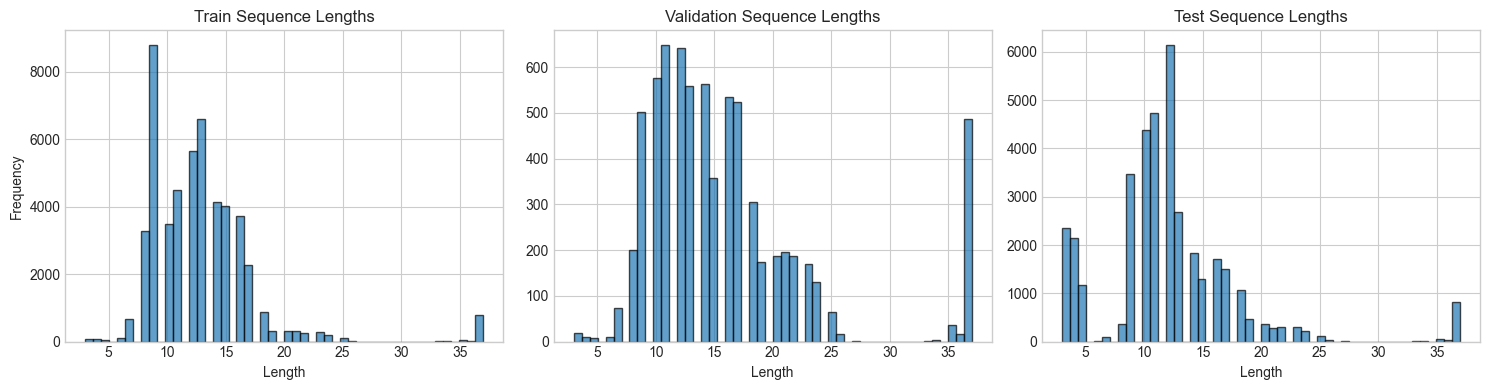

Train - Min: 3, Max: 37, Mean: 12.81
Val - Min: 3, Max: 37, Mean: 16.01
Test - Min: 3, Max: 37, Mean: 12.03


In [5]:
# Phân phối độ dài chuỗi
train_lengths = [len(seq) for seq in train_sequences]
val_lengths = [len(seq) for seq in val_sequences]
test_lengths = [len(seq) for seq in test_sequences]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Train Sequence Lengths')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Frequency')

axes[1].hist(val_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Validation Sequence Lengths')
axes[1].set_xlabel('Length')

axes[2].hist(test_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[2].set_title('Test Sequence Lengths')
axes[2].set_xlabel('Length')

plt.tight_layout()
plt.savefig('../outputs/figures/sequence_length_distribution.png', dpi=150)
plt.show()

print(f"Train - Min: {min(train_lengths)}, Max: {max(train_lengths)}, Mean: {np.mean(train_lengths):.2f}")
print(f"Val - Min: {min(val_lengths)}, Max: {max(val_lengths)}, Mean: {np.mean(val_lengths):.2f}")
print(f"Test - Min: {min(test_lengths)}, Max: {max(test_lengths)}, Mean: {np.mean(test_lengths):.2f}")


In [6]:
# Phân tích từ vựng action
all_train_actions = np.concatenate(train_sequences)
action_counts = Counter(all_train_actions)

print(f"Total unique actions: {len(action_counts)}")
print(f"Total action occurrences: {len(all_train_actions)}")
print(f"\nTop 20 most common actions:")
for action, count in action_counts.most_common(20):
    print(f"  Action {action}: {count} ({count/len(all_train_actions)*100:.2f}%)")


Total unique actions: 254
Total action occurrences: 653378

Top 20 most common actions:
  Action 105: 56478 (8.64%)
  Action 102: 41036 (6.28%)
  Action 103: 25704 (3.93%)
  Action 760: 18524 (2.84%)
  Action 8615: 18396 (2.82%)
  Action 685: 16949 (2.59%)
  Action 697: 13856 (2.12%)
  Action 867: 10537 (1.61%)
  Action 929: 10270 (1.57%)
  Action 975: 9564 (1.46%)
  Action 606: 9532 (1.46%)
  Action 836: 9368 (1.43%)
  Action 7943: 9345 (1.43%)
  Action 1165: 9331 (1.43%)
  Action 10477: 9261 (1.42%)
  Action 2207: 9241 (1.41%)
  Action 15342: 9225 (1.41%)
  Action 1593: 9188 (1.41%)
  Action 17980: 9185 (1.41%)
  Action 21606: 9169 (1.40%)


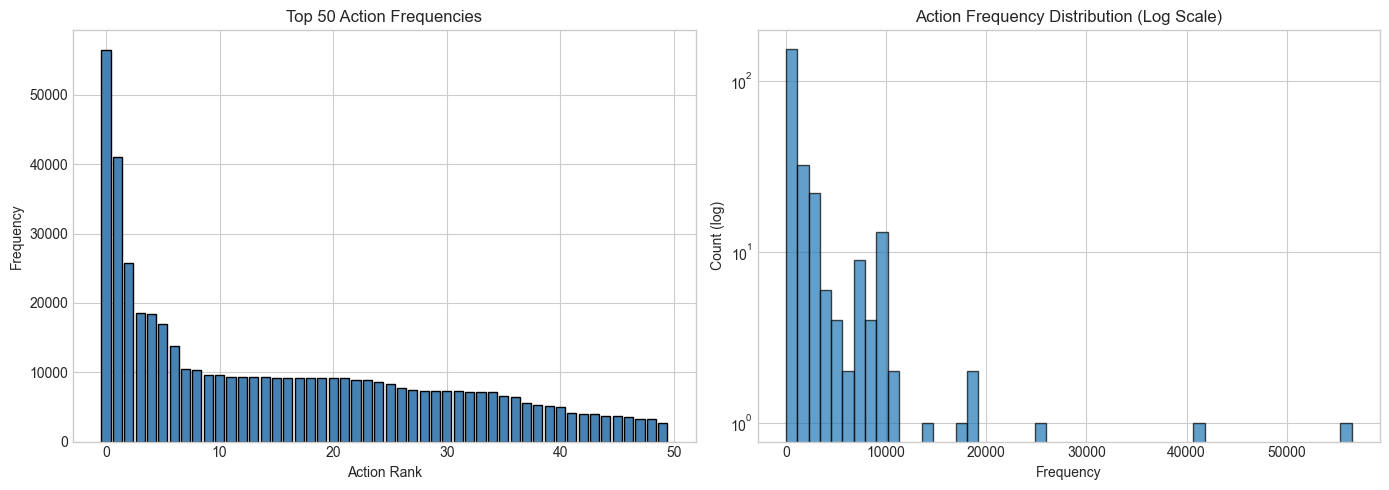

In [7]:
# Phân phối tần suất action
action_freqs = list(action_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(min(50, len(action_counts))), 
            [c for _, c in action_counts.most_common(50)],
            color='steelblue', edgecolor='black')
axes[0].set_title('Top 50 Action Frequencies')
axes[0].set_xlabel('Action Rank')
axes[0].set_ylabel('Frequency')

axes[1].hist(action_freqs, bins=50, edgecolor='black', alpha=0.7, log=True)
axes[1].set_title('Action Frequency Distribution (Log Scale)')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Count (log)')

plt.tight_layout()
plt.savefig('../outputs/figures/action_frequency_distribution.png', dpi=150)
plt.show()


## 3. Phân Tích Phân Phối Nhãn Đích


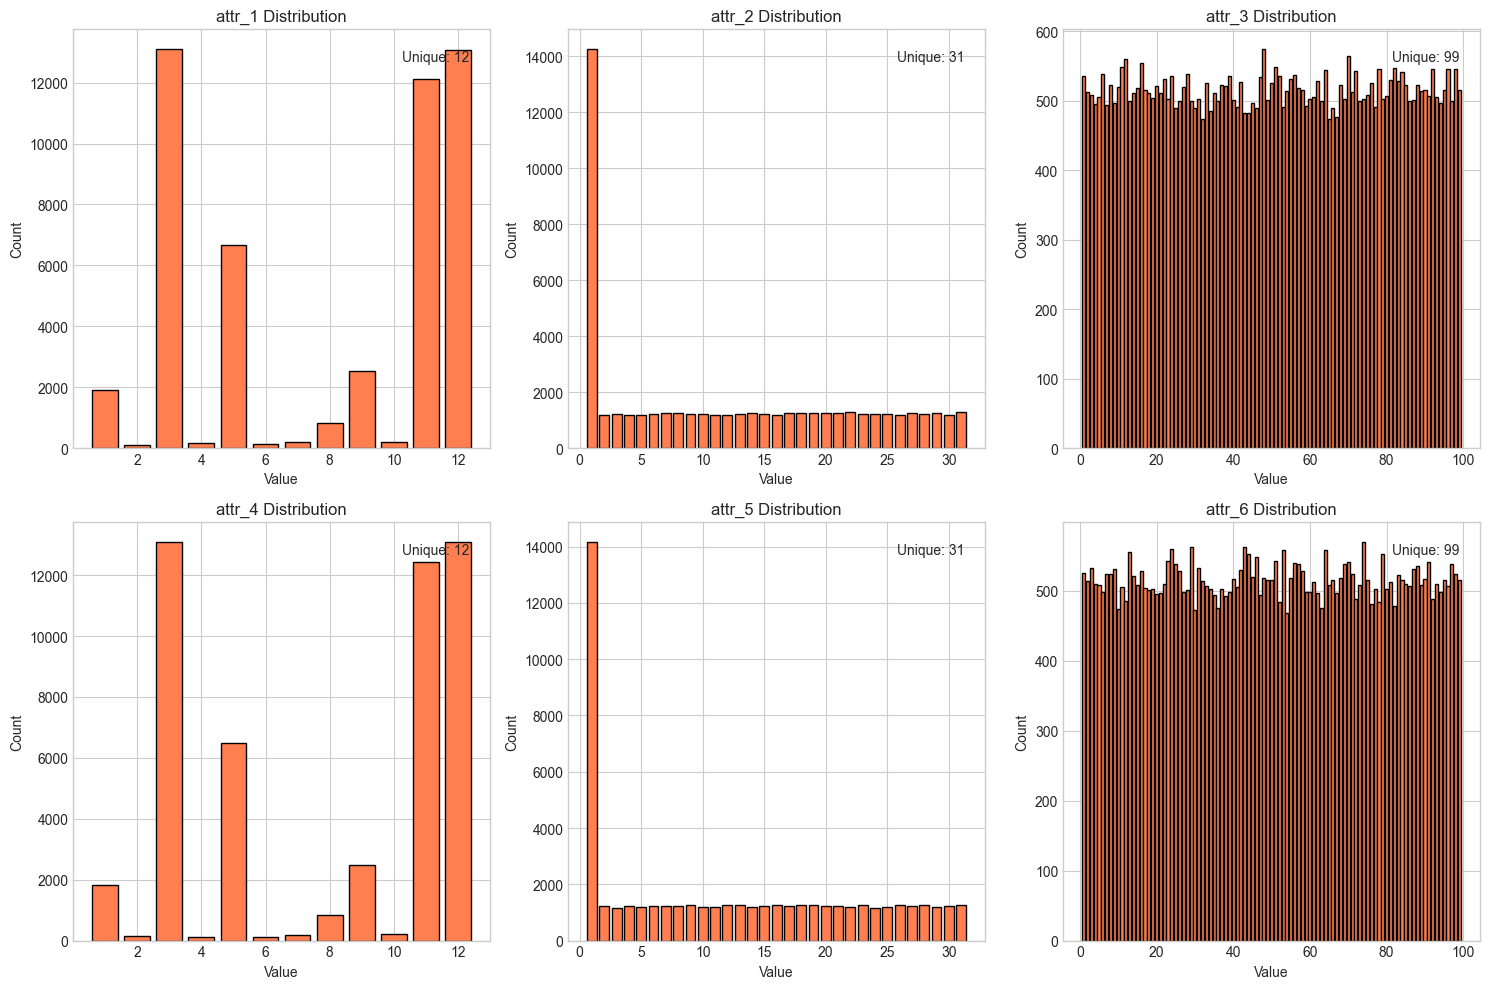

In [8]:
# Phân phối giá trị nhãn đích
target_cols = ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    values = Y_train[col].value_counts().sort_index()
    axes[i].bar(values.index, values.values, color='coral', edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    
    # Thêm thống kê
    n_unique = Y_train[col].nunique()
    axes[i].text(0.95, 0.95, f'Unique: {n_unique}', 
                 transform=axes[i].transAxes, ha='right', va='top')

plt.tight_layout()
plt.savefig('../outputs/figures/target_distributions.png', dpi=150)
plt.show()


In [9]:
# Thống kê nhãn đích
print("Target Statistics (Training Set):")
print(Y_train[target_cols].describe())


Target Statistics (Training Set):
             attr_1        attr_2        attr_3        attr_4        attr_5  \
count  51000.000000  51000.000000  51000.000000  51000.000000  51000.000000   
mean       7.822392     12.225529     50.063647      7.865098     12.226608   
std        3.980223     10.132358     28.641257      3.975927     10.118196   
min        1.000000      1.000000      1.000000      1.000000      1.000000   
25%        3.000000      1.000000     25.000000      3.000000      1.000000   
50%        9.000000     11.000000     50.000000     11.000000     11.000000   
75%       12.000000     21.000000     75.000000     12.000000     21.000000   
max       12.000000     31.000000     99.000000     12.000000     31.000000   

             attr_6  
count  51000.000000  
mean      50.011941  
std       28.570030  
min        1.000000  
25%       25.000000  
50%       50.000000  
75%       75.000000  
max       99.000000  


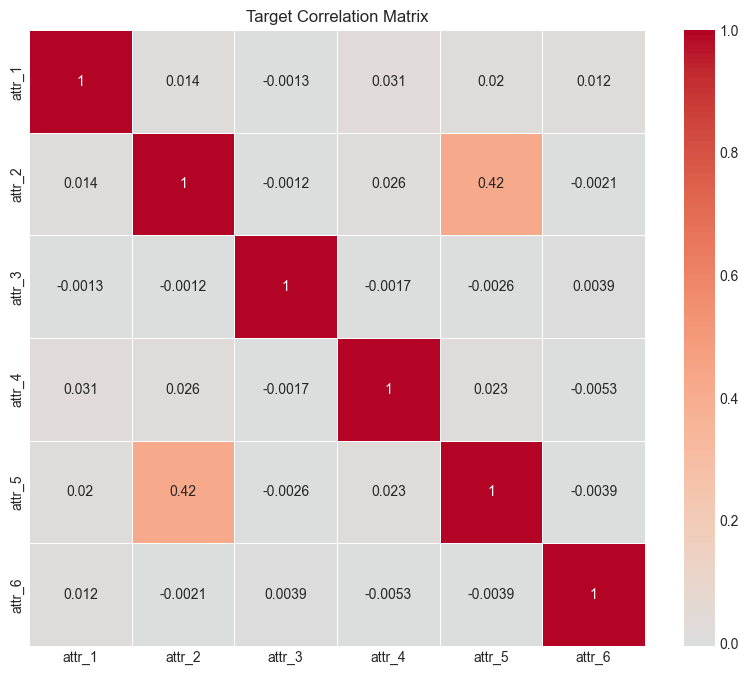


Note: Targets are expected to be INDEPENDENT per problem statement.


In [10]:
# Phân tích tương quan nhãn đích
plt.figure(figsize=(10, 8))
corr_matrix = Y_train[target_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Target Correlation Matrix')
plt.savefig('../outputs/figures/target_correlation.png', dpi=150)
plt.show()

print("\nNote: Targets are expected to be INDEPENDENT per problem statement.")


### 3.1 Phân Tích Mất Cân Bằng Lớp cho Từng Nhãn Đích


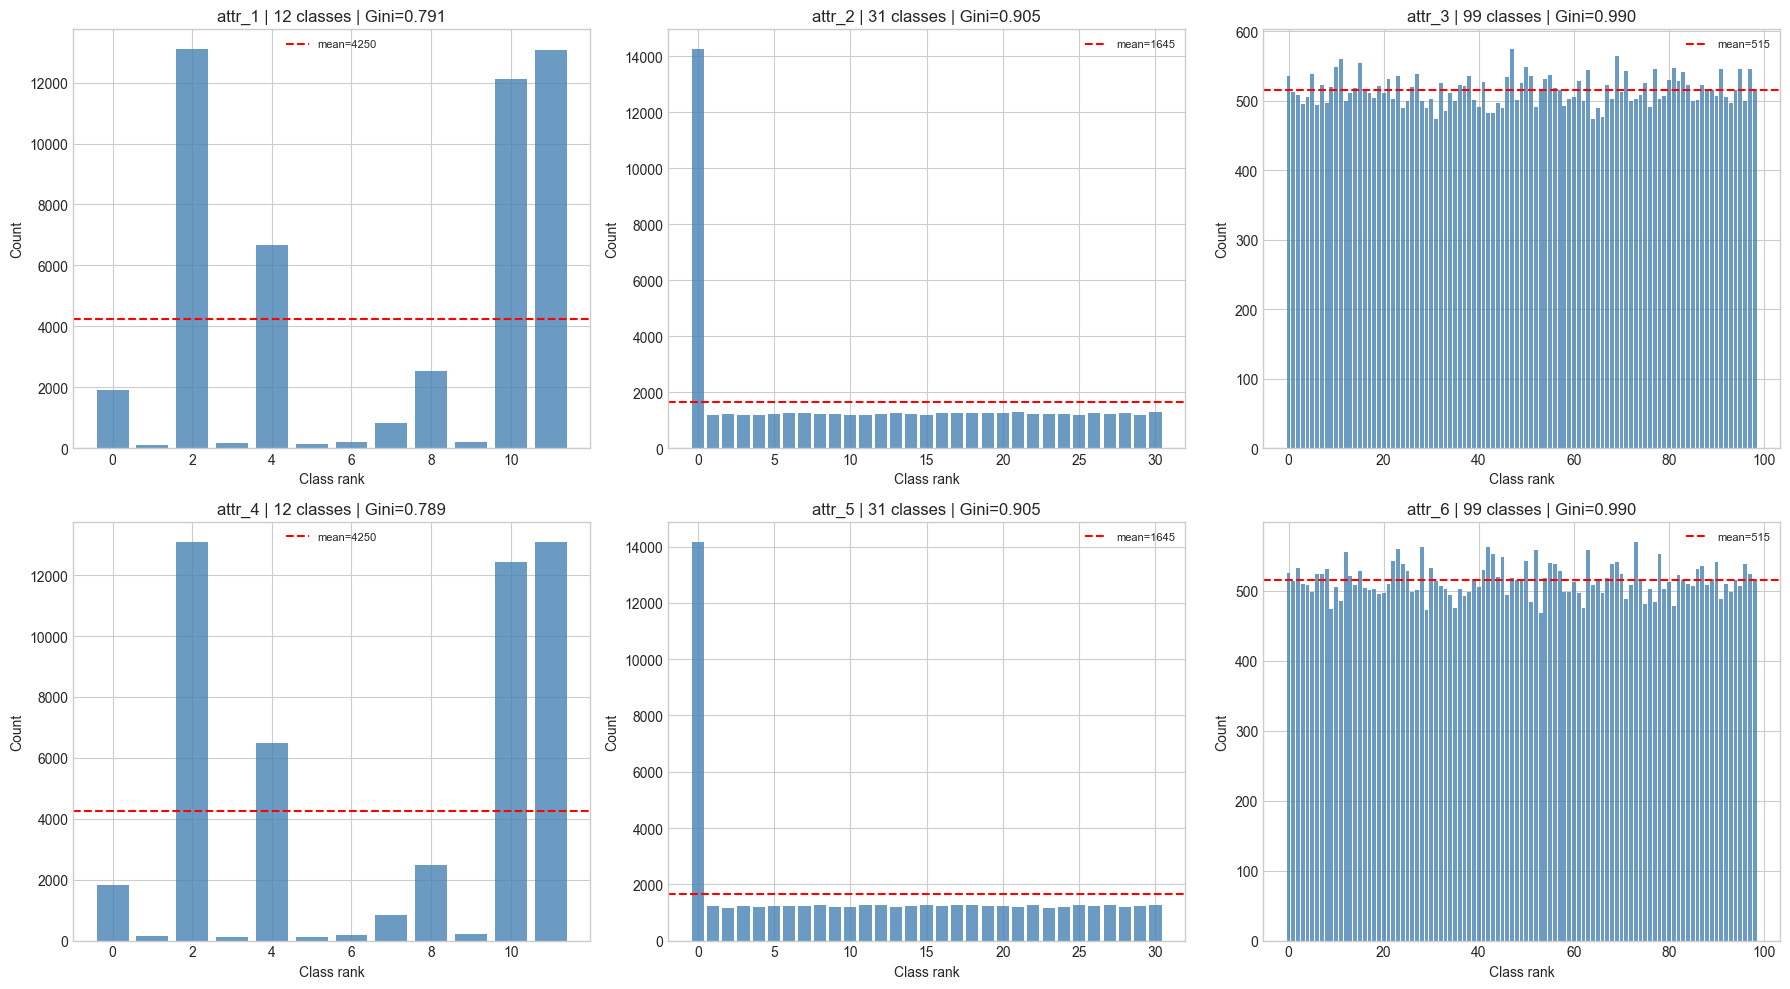

Class balance summary:
  attr_1: 12 classes | min_count=117 | max_count=13092 | ratio=111.9x
  attr_2: 31 classes | min_count=1170 | max_count=14248 | ratio=12.2x
  attr_3: 99 classes | min_count=474 | max_count=574 | ratio=1.2x
  attr_4: 12 classes | min_count=119 | max_count=13093 | ratio=110.0x
  attr_5: 31 classes | min_count=1152 | max_count=14170 | ratio=12.3x
  attr_6: 99 classes | min_count=469 | max_count=570 | ratio=1.2x


In [11]:

# Phân tích mất cân bằng lớp: Gini impurity cho từng nhãn đích
# attr_3 và attr_6 có 99 lớp — chúng có cân bằng không?
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    vc = Y_train[col].value_counts().sort_index()
    n = len(Y_train)
    gini = 1 - sum((c / n) ** 2 for c in vc.values)

    axes[i].bar(range(len(vc)), vc.values, color='steelblue', alpha=0.8)
    axes[i].set_title(f'{col} | {len(vc)} classes | Gini={gini:.3f}')
    axes[i].set_xlabel('Class rank')
    axes[i].set_ylabel('Count')

    # Đánh dấu lớp min/max
    axes[i].axhline(vc.values.mean(), color='red', linestyle='--', label=f'mean={vc.values.mean():.0f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/class_imbalance_per_target.png', dpi=150)
plt.show()

print("Class balance summary:")
for col in target_cols:
    vc = Y_train[col].value_counts()
    print(f"  {col}: {Y_train[col].nunique()} classes | "
          f"min_count={vc.min()} | max_count={vc.max()} | "
          f"ratio={vc.max()/vc.min():.1f}x")


### 3.2 Phân Tích Chuyên Sâu Cấu Trúc Thuộc Tính

Khám phá cấu trúc ẩn giữa 6 thuộc tính nhãn đích — tìm kiếm "các mẫu hành vi ẩn đằng sau các con số được mã hóa".


#### 3.2.1 Ma Trận Liên Kết Xuyên Thuộc Tính

Tương quan Pearson chỉ đo mối quan hệ tuyến tính — không phù hợp cho nhãn đích dạng categorical.
Sử dụng **Cramer's V** (liên kết categorical) và **Mutual Information** để phát hiện mối quan hệ phi tuyến.


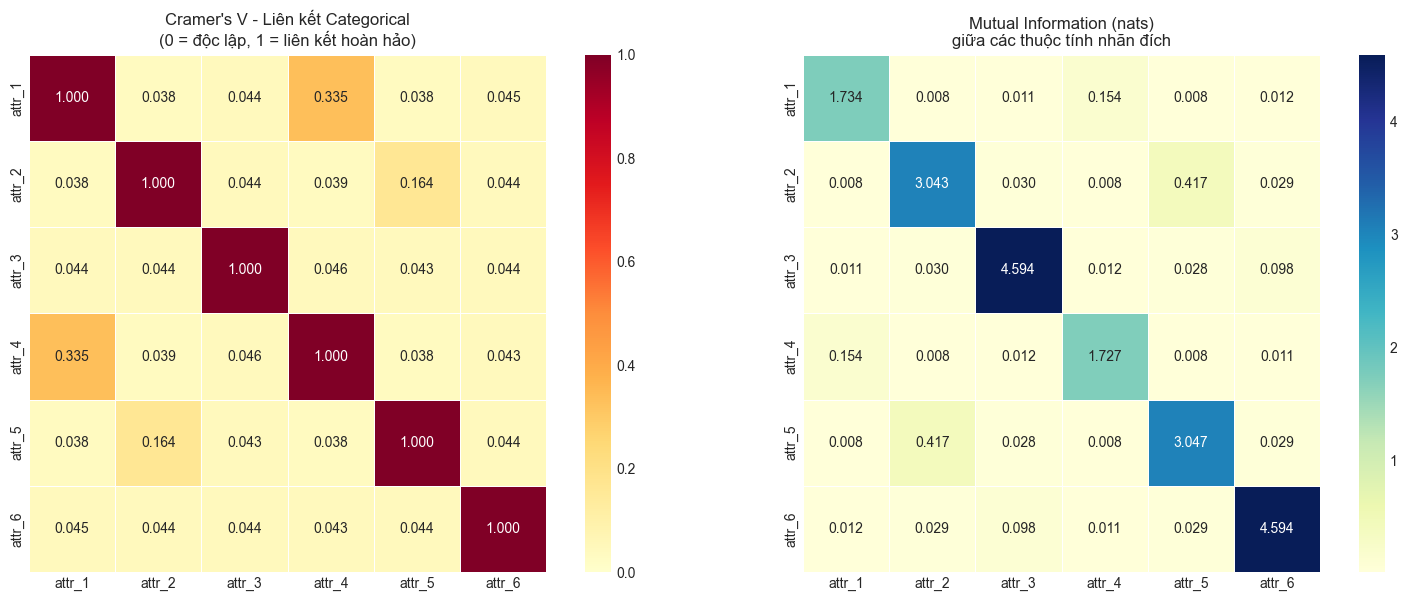

Key findings:
  attr_1 <-> attr_4: Cramer's V = 0.3351, MI = 0.1536
  attr_2 <-> attr_5: Cramer's V = 0.1637, MI = 0.4170
  attr_3 <-> attr_6: Cramer's V = 0.0438, MI = 0.0982


In [12]:
from sklearn.metrics import mutual_info_score
from scipy.stats.contingency import association

target_cols = ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']
n_targets = len(target_cols)

# Ma trận Cramer's V và Mutual Information
cramers_v_matrix = np.zeros((n_targets, n_targets))
mi_matrix = np.zeros((n_targets, n_targets))

for i in range(n_targets):
    for j in range(n_targets):
        a = Y_train[target_cols[i]].values
        b = Y_train[target_cols[j]].values
        ct = pd.crosstab(a, b)
        cramers_v_matrix[i, j] = association(ct.values, method='cramer')
        mi_matrix[i, j] = mutual_info_score(a, b)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cramers_v_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=target_cols, yticklabels=target_cols,
            ax=axes[0], vmin=0, vmax=1, square=True, linewidths=0.5)
axes[0].set_title("Cramer's V - Liên kết Categorical\n(0 = độc lập, 1 = liên kết hoàn hảo)")

sns.heatmap(mi_matrix, annot=True, fmt='.3f', cmap='YlGnBu',
            xticklabels=target_cols, yticklabels=target_cols,
            ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Mutual Information (nats)\ngiữa các thuộc tính nhãn đích')

plt.tight_layout()
plt.savefig('../outputs/figures/attribute_association_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key findings:")
pairs = [(0,3), (1,4), (2,5)]
pair_names = [('attr_1','attr_4'), ('attr_2','attr_5'), ('attr_3','attr_6')]
for (i,j), (n1,n2) in zip(pairs, pair_names):
    print(f"  {n1} <-> {n2}: Cramer's V = {cramers_v_matrix[i,j]:.4f}, MI = {mi_matrix[i,j]:.4f}")


#### 3.2.2 Tương Quan Action–Nhãn Đích
Tìm action nào có tương quan mạnh nhất với từng thuộc tính nhãn đích.


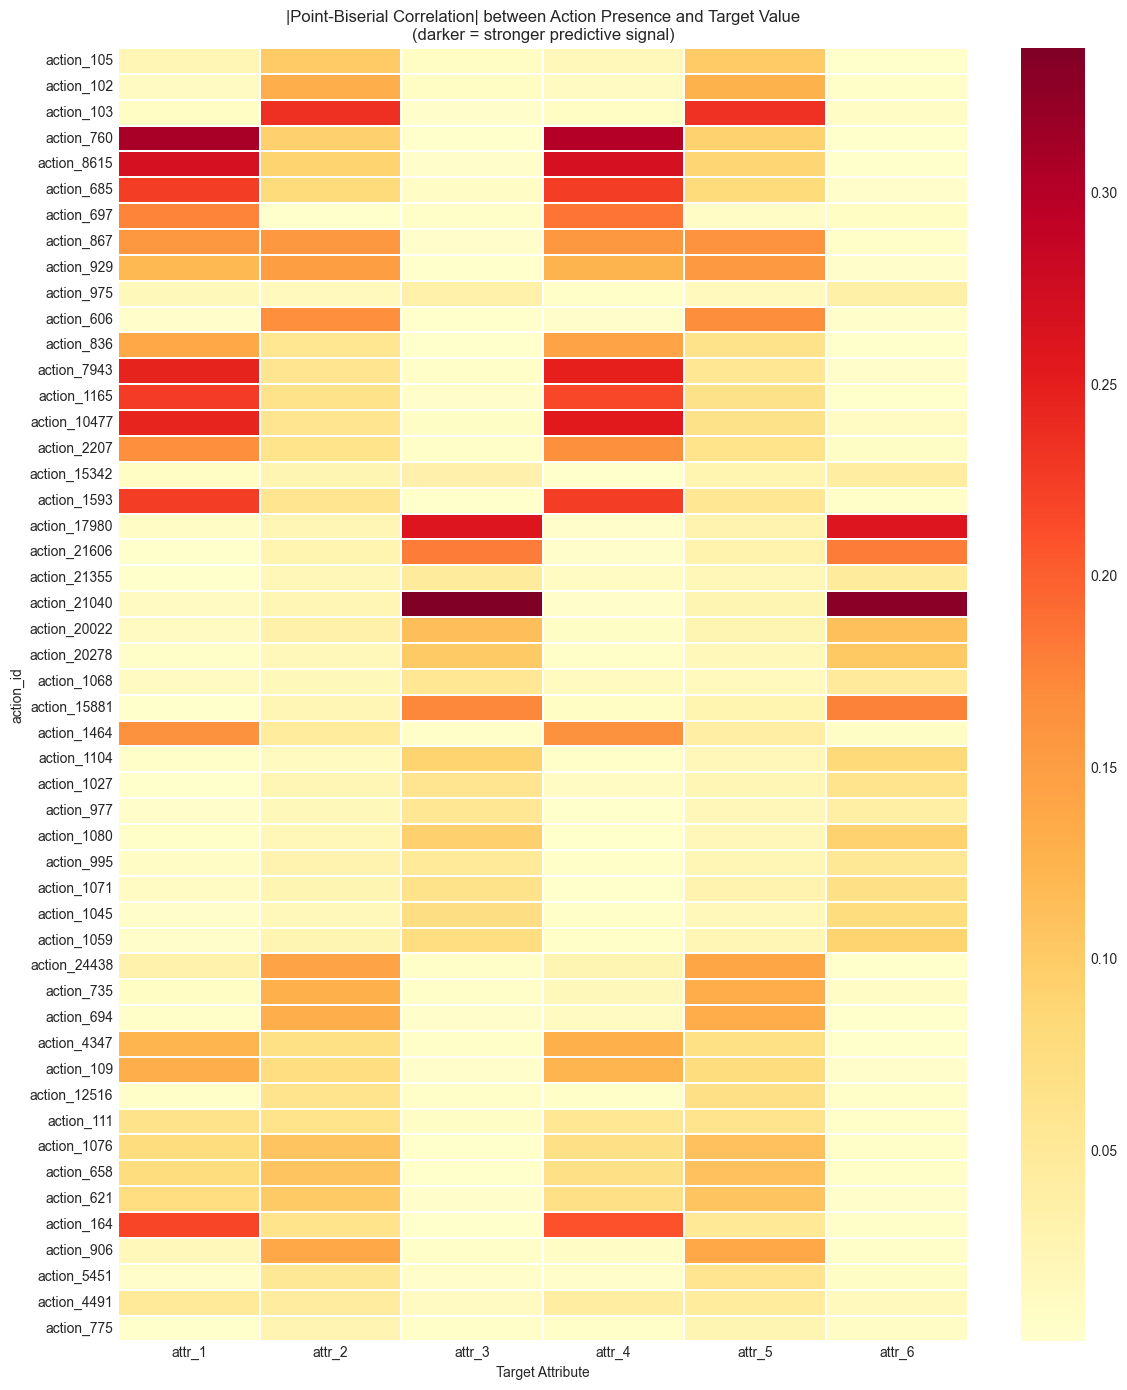


Top 5 most predictive actions per attribute:
  attr_1: [760, 8615, 7943, 10477, 1165] (r=[0.31, 0.269, 0.246, 0.245, 0.227])
  attr_2: [103, 606, 867, 929, 24438] (r=[0.236, 0.167, 0.158, 0.149, 0.143])
  attr_3: [21040, 17980, 21606, 15881, 20022] (r=[0.338, 0.261, 0.181, 0.172, 0.113])
  attr_4: [760, 8615, 10477, 7943, 1593] (r=[0.302, 0.269, 0.254, 0.248, 0.225])
  attr_5: [103, 606, 867, 929, 24438] (r=[0.234, 0.168, 0.162, 0.156, 0.142])
  attr_6: [21040, 17980, 21606, 15881, 20022] (r=[0.329, 0.261, 0.18, 0.176, 0.112])


In [13]:

from scipy.stats import pointbiserialr

# Top 50 action phổ biến nhất
top_actions = [a for a, _ in action_counts.most_common(50)]

# Tính tương quan point-biserial cho từng action với mỗi nhãn đích
# has_action[i] = 1 nếu action i xuất hiện trong chuỗi, ngược lại 0
correlation_rows = []
for action_id in top_actions:
    has_action = np.array([int(action_id in set(seq)) for seq in train_sequences])
    row = {'action_id': action_id, 'freq': action_counts[action_id]}
    for col in target_cols:
        r, p = pointbiserialr(has_action, Y_train[col].values)
        row[col] = r
    correlation_rows.append(row)

corr_df = pd.DataFrame(correlation_rows).set_index('action_id')

# Heatmap độ mạnh |tương quan|
fig, ax = plt.subplots(figsize=(12, 14))
corr_vals = corr_df[target_cols].abs()
sns.heatmap(
    corr_vals,
    ax=ax,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    yticklabels=[f"action_{int(a)}" for a in corr_df.index],
)
ax.set_title('|Point-Biserial Correlation| between Action Presence and Target Value\n(darker = stronger predictive signal)')
ax.set_xlabel('Target Attribute')
plt.tight_layout()
plt.savefig('../outputs/figures/action_target_correlation.png', dpi=150)
plt.show()

# Top 5 action dự đoán tốt nhất cho mỗi thuộc tính
print("\nTop 5 most predictive actions per attribute:")
for col in target_cols:
    top5 = corr_df[col].abs().nlargest(5)
    print(f"  {col}: {top5.index.tolist()} (r={top5.values.round(3).tolist()})")


#### 3.2.3 Nghịch Lý Cặp Đối Xứng

Phát hiện quan trọng: attr_1/attr_4, attr_2/attr_5, attr_3/attr_6 có cùng tập action có tính dự đoán mạnh nhất,
nhưng tương quan Pearson rất thấp (0.03, 0.42, 0.004). Tại sao?

**Giả thuyết**: Có 3 không gian đặc trưng, mỗi không gian mã hóa 2 khía cạnh trực giao (độc lập) của hành vi.


Conditional Entropy Analysis (mirrored pairs):
Pair                 H(B|A)     H(A|B)     H(A)       H(B)       Pearson r 
------------------------------------------------------------
  attr_1/attr_4         1.5738     1.5802     1.7338     1.7274     0.0306    
  attr_2/attr_5         2.6298     2.6261     3.0431     3.0468     0.4220    
  attr_3/attr_6         4.4960     4.4961     4.5943     4.5942     0.0039    

Diễn giải:
  H(B|A) gần bằng H(B) => biết A hầu như không cho biết gì về B
  => Các cặp đối xứng thực sự độc lập dù chia sẻ cùng action dự đoán


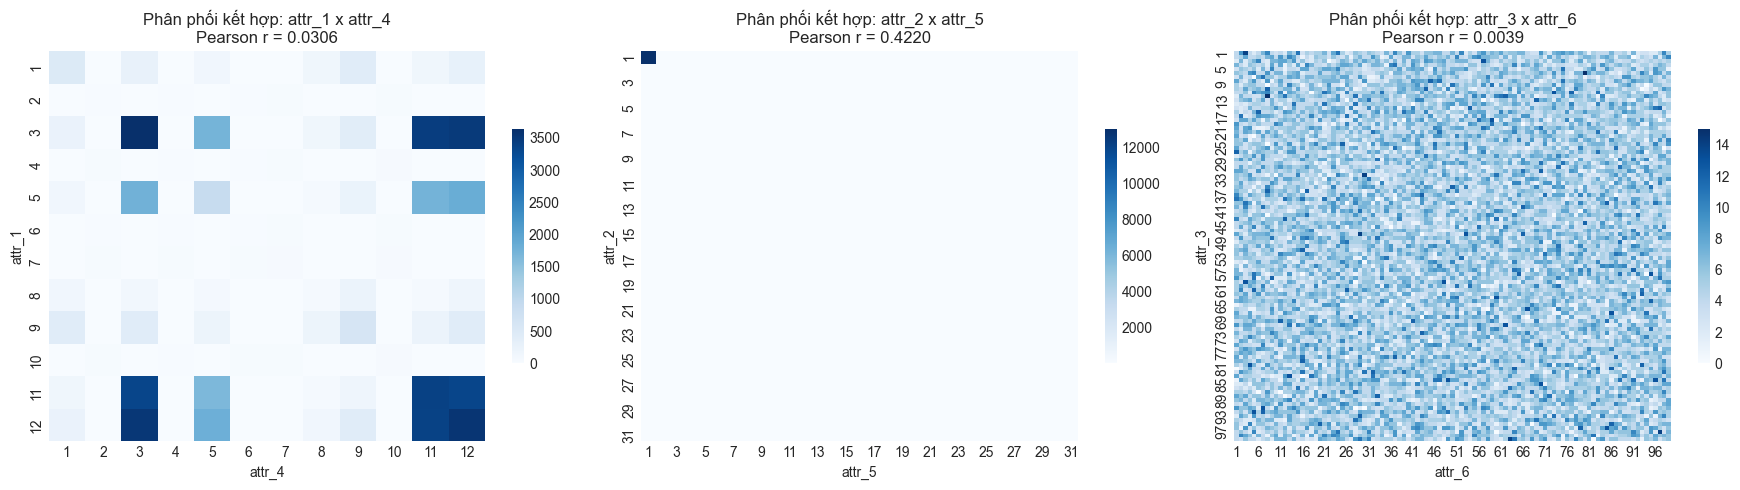

In [14]:
from scipy.stats import entropy as sp_entropy

def conditional_entropy(x, y):
    """H(Y|X) - độ bất định còn lại trong Y sau khi biết X."""
    xy = list(zip(x, y))
    h_xy = sp_entropy(list(Counter(xy).values()))
    h_x = sp_entropy(list(Counter(x).values()))
    return h_xy - h_x

mirror_pairs = [('attr_1', 'attr_4'), ('attr_2', 'attr_5'), ('attr_3', 'attr_6')]

print("Conditional Entropy Analysis (mirrored pairs):")
print(f"{'Pair':<20} {'H(B|A)':<10} {'H(A|B)':<10} {'H(A)':<10} {'H(B)':<10} {'Pearson r':<10}")
print("-" * 60)
for a_col, b_col in mirror_pairs:
    a = Y_train[a_col].values
    b = Y_train[b_col].values
    h_b_given_a = conditional_entropy(a, b)
    h_a_given_b = conditional_entropy(b, a)
    h_a = sp_entropy(list(Counter(a).values()))
    h_b = sp_entropy(list(Counter(b).values()))
    pearson_r = np.corrcoef(a, b)[0, 1]
    print(f"  {a_col}/{b_col:<14} {h_b_given_a:<10.4f} {h_a_given_b:<10.4f} {h_a:<10.4f} {h_b:<10.4f} {pearson_r:<10.4f}")

print("\nDiễn giải:")
print("  H(B|A) gần bằng H(B) => biết A hầu như không cho biết gì về B")
print("  => Các cặp đối xứng thực sự độc lập dù chia sẻ cùng action dự đoán")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (a_col, b_col) in enumerate(mirror_pairs):
    ct = pd.crosstab(Y_train[a_col], Y_train[b_col])
    sns.heatmap(ct, ax=axes[idx], cmap='Blues', cbar_kws={'shrink': 0.6})
    r = np.corrcoef(Y_train[a_col], Y_train[b_col])[0,1]
    axes[idx].set_title(f'Phân phối kết hợp: {a_col} x {b_col}\nPearson r = {r:.4f}')
    axes[idx].set_xlabel(b_col)
    axes[idx].set_ylabel(a_col)

plt.tight_layout()
plt.savefig('../outputs/figures/mirrored_pair_joint_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Cho thấy các cặp đối xứng chia sẻ cùng top action dự đoán
# Tái dùng corr_df từ Section 3A (đã tính tương quan point-biserial)

print("Top 10 predictive actions per attribute (|point-biserial r|):\n")
for col in target_cols:
    top10 = corr_df[col].abs().nlargest(10)
    actions_str = ', '.join([str(int(a)) for a in top10.index])
    print(f"  {col}: [{actions_str}]")

print("\nCác action chung giữa các cặp đối xứng:")
for a_col, b_col in mirror_pairs:
    top_a = set(corr_df[a_col].abs().nlargest(10).index)
    top_b = set(corr_df[b_col].abs().nlargest(10).index)
    shared = top_a & top_b
    print(f"  {a_col} & {b_col}: {len(shared)}/10 chung - {sorted([int(x) for x in shared])}")

print("\nKết luận: Mỗi cặp đối xứng sử dụng CÙNG đặc trưng action")
print("nhưng trích xuất thông tin TRỰC GIAO từ chúng.")
print("=> 3 không gian đặc trưng x 2 khía cạnh độc lập mỗi không gian.")


Top 10 predictive actions per attribute (|point-biserial r|):

  attr_1: [760, 8615, 7943, 10477, 1165, 1593, 685, 164, 697, 2207]
  attr_2: [103, 606, 867, 929, 24438, 906, 694, 102, 735, 1076]
  attr_3: [21040, 17980, 21606, 15881, 20022, 20278, 1080, 1104, 1059, 1045]
  attr_4: [760, 8615, 10477, 7943, 1593, 685, 1165, 164, 697, 2207]
  attr_5: [103, 606, 867, 929, 24438, 906, 735, 694, 102, 1076]
  attr_6: [21040, 17980, 21606, 15881, 20022, 20278, 1080, 1059, 1104, 1045]

Các action chung giữa các cặp đối xứng:
  attr_1 & attr_4: 10/10 chung - [164, 685, 697, 760, 1165, 1593, 2207, 7943, 8615, 10477]
  attr_2 & attr_5: 10/10 chung - [102, 103, 606, 694, 735, 867, 906, 929, 1076, 24438]
  attr_3 & attr_6: 10/10 chung - [1045, 1059, 1080, 1104, 15881, 17980, 20022, 20278, 21040, 21606]

Kết luận: Mỗi cặp đối xứng sử dụng CÙNG đặc trưng action
nhưng trích xuất thông tin TRỰC GIAO từ chúng.
=> 3 không gian đặc trưng x 2 khía cạnh độc lập mỗi không gian.


#### 3.2.4 Phân Tích Tổ Hợp Nhãn Đích (Trọng Tâm Exact-Match)

Vì metric chính là Exact-Match Accuracy (tất cả 6 thuộc tính phải đúng),
ta cần hiểu phân phối của bộ 6 (attr_1,...,attr_6) — có bao nhiêu tổ hợp thực sự xuất hiện?


Unique 6-tuples in training: 50,631
Theoretical maximum: 1,356,301,584
Sparsity: 0.003733% of space is realized
Concentration: top-1 tuple covers 0.01% of samples
  Top-10 tuples cover 0.1% of training data
  Top-50 tuples cover 0.2% of training data
  Top-100 tuples cover 0.4% of training data
  Top-500 tuples cover 1.7% of training data
  Top-1000 tuples cover 2.7% of training data


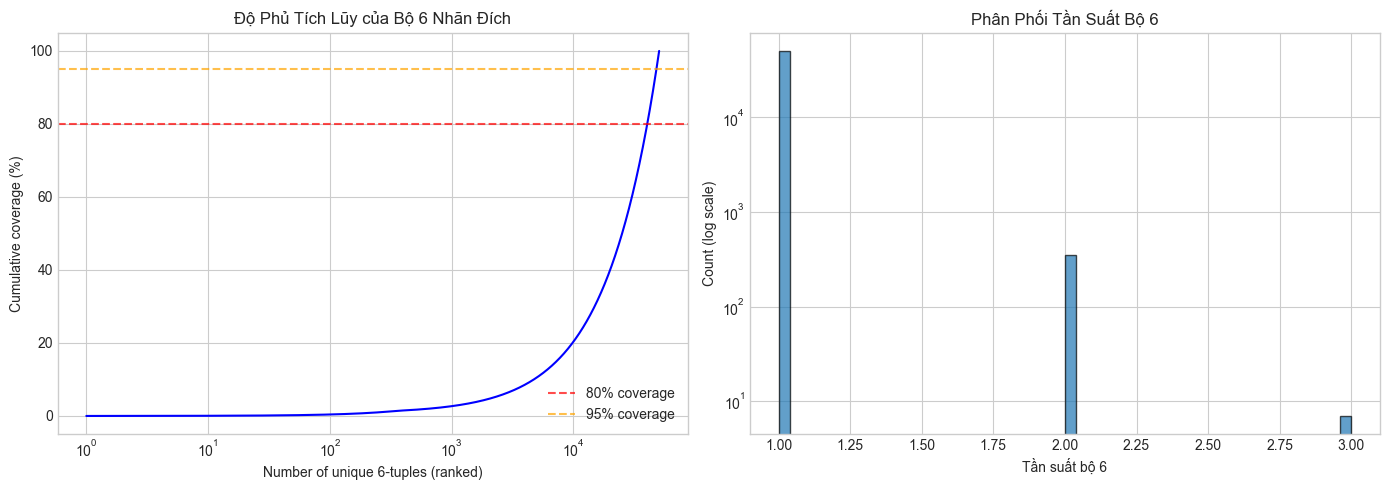


Singletons (appear exactly once): 50269 (99.3% of unique tuples)
Implication for exact-match: ensemble can exploit combination sparsity


In [16]:
# Đếm số bộ 6 duy nhất
tuples = Y_train[target_cols].apply(tuple, axis=1)
tuple_counts = tuples.value_counts()

n_unique = len(tuple_counts)
n_possible = np.prod([Y_train[c].nunique() for c in target_cols])

print(f"Unique 6-tuples in training: {n_unique:,}")
print(f"Theoretical maximum: {n_possible:,}")
print(f"Sparsity: {n_unique / n_possible * 100:.6f}% of space is realized")
print(f"Concentration: top-1 tuple covers {tuple_counts.iloc[0] / len(Y_train) * 100:.2f}% of samples")

# Độ phủ Top-K
cumsum = tuple_counts.cumsum() / len(Y_train) * 100
for k in [10, 50, 100, 500, 1000]:
    if k <= len(cumsum):
        print(f"  Top-{k} tuples cover {cumsum.iloc[k-1]:.1f}% of training data")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(cumsum) + 1), cumsum.values, 'b-', linewidth=1.5)
axes[0].axhline(y=80, color='r', linestyle='--', alpha=0.7, label='80% coverage')
axes[0].axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95% coverage')
axes[0].set_xlabel('Number of unique 6-tuples (ranked)')
axes[0].set_ylabel('Cumulative coverage (%)')
axes[0].set_title('Độ Phủ Tích Lũy của Bộ 6 Nhãn Đích')
axes[0].legend()
axes[0].set_xscale('log')

axes[1].hist(tuple_counts.values, bins=50, edgecolor='black', alpha=0.7, log=True)
axes[1].set_xlabel('Tần suất bộ 6')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Phân Phối Tần Suất Bộ 6')

plt.tight_layout()
plt.savefig('../outputs/figures/target_combination_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

singletons = (tuple_counts == 1).sum()
print(f"\nSingletons (appear exactly once): {singletons} ({singletons/n_unique*100:.1f}% of unique tuples)")
print(f"Implication for exact-match: ensemble can exploit combination sparsity")


#### 3.2.5 Khám Phá Không Gian Kết Hợp attr_1 x attr_4

attr_1 và attr_4 đều có 12 lớp => tối đa 144 tổ hợp. Nhưng bao nhiêu tổ hợp thực sự xuất hiện?
Khám phá các ràng buộc cấu trúc trong không gian nhãn đích.


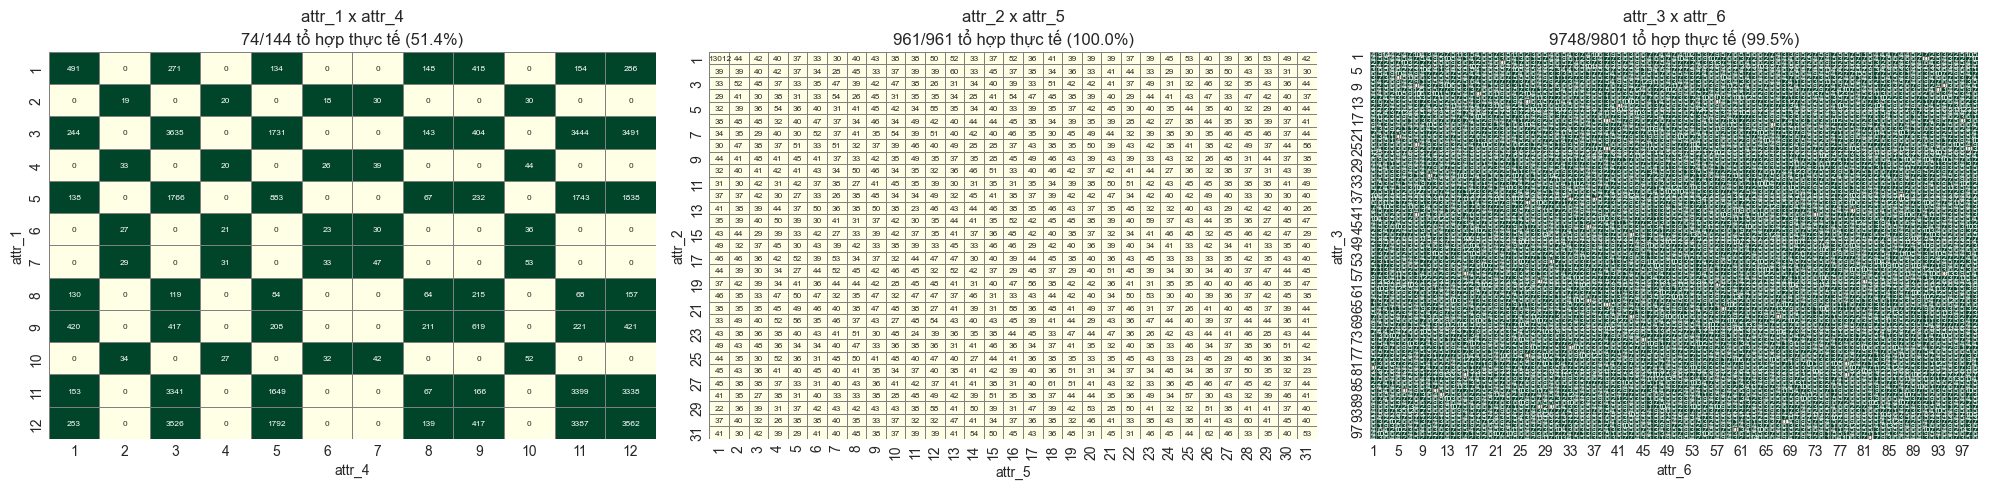

Tóm tắt ràng buộc cấu trúc:
  attr_1 x attr_4: 74/144 thực tế (51.4%)
  attr_2 x attr_5: 961/961 thực tế (100.0%)
  attr_3 x attr_6: 9748/9801 thực tế (99.5%)

Diễn giải nghiệp vụ:
  Ràng buộc cấu trúc = không phải mọi tổ hợp thuộc tính đều hợp lệ
  => Một số mẫu hành vi kho hàng xung đột nhau
  => Mô hình có thể học để tránh các tổ hợp không thể xảy ra


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (a_col, b_col) in enumerate(mirror_pairs):
    ct = pd.crosstab(Y_train[a_col], Y_train[b_col])
    n_possible_pair = Y_train[a_col].nunique() * Y_train[b_col].nunique()
    n_realized = (ct > 0).sum().sum()

    realized = (ct > 0).astype(int)
    sns.heatmap(realized, ax=axes[idx], cmap='YlGn', cbar=False,
                linewidths=0.5, linecolor='gray',
                annot=ct.values, fmt='d', annot_kws={'size': 6})
    axes[idx].set_title(f'{a_col} x {b_col}\n{n_realized}/{n_possible_pair} tổ hợp thực tế ({n_realized/n_possible_pair*100:.1f}%)')
    axes[idx].set_xlabel(b_col)
    axes[idx].set_ylabel(a_col)

plt.tight_layout()
plt.savefig('../outputs/figures/joint_space_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print("Tóm tắt ràng buộc cấu trúc:")
for a_col, b_col in mirror_pairs:
    ct = pd.crosstab(Y_train[a_col], Y_train[b_col])
    n_possible_pair = Y_train[a_col].nunique() * Y_train[b_col].nunique()
    n_realized = (ct > 0).sum().sum()
    print(f"  {a_col} x {b_col}: {n_realized}/{n_possible_pair} thực tế ({n_realized/n_possible_pair*100:.1f}%)")

print("\nDiễn giải nghiệp vụ:")
print("  Ràng buộc cấu trúc = không phải mọi tổ hợp thuộc tính đều hợp lệ")
print("  => Một số mẫu hành vi kho hàng xung đột nhau")
print("  => Mô hình có thể học để tránh các tổ hợp không thể xảy ra")


#### Kết Luận - Mục 3.2

| Phát Hiện | Chi Tiết |
|---------|--------|
| Cramer's V xác nhận độc lập | Hầu hết các cặp thuộc tính có V < 0.05 |
| Nghịch lý cặp đối xứng | attr_1/4, attr_2/5, attr_3/6 chia sẻ đặc trưng dự đoán nhưng trực giao nhau |
| 3 không gian đặc trưng | Mỗi không gian mã hóa 2 khía cạnh độc lập của hành vi |
| Không gian nhãn thưa | Chỉ một phần nhỏ của các bộ 6 khả năng được thực hiện |
| Ràng buộc cấu trúc | Các cặp đối xứng có ít tổ hợp thực tế hơn lý thuyết tối đa |


## 4. Phân Tích Hành Vi Khách Hàng


In [18]:
# Phân tích mẫu chuỗi
def analyze_sequence(seq):
    """Trích xuất các đặc trưng hành vi từ một chuỗi."""
    return {
        'length': len(seq),
        'unique_actions': len(set(seq)),
        'uniqueness_ratio': len(set(seq)) / len(seq) if len(seq) > 0 else 0,
        'most_common_action': Counter(seq).most_common(1)[0][0] if len(seq) > 0 else -1,
        'most_common_freq': Counter(seq).most_common(1)[0][1] / len(seq) if len(seq) > 0 else 0,
        'entropy': stats.entropy(list(Counter(seq).values())) if len(seq) > 0 else 0,
    }

train_behaviors = pd.DataFrame([analyze_sequence(seq) for seq in train_sequences])
train_behaviors.head(10)


,length,unique_actions,uniqueness_ratio,most_common_action,most_common_freq,entropy
0,8,7,0.875000,109,0.250000,1.906155
1,9,8,0.888889,685,0.222222,2.043192
2,15,14,0.933333,102,0.133333,2.615631
3,11,9,0.818182,102,0.181818,2.145842
4,13,12,0.923077,102,0.153846,2.458311
5,10,9,0.900000,105,0.200000,2.163956
6,12,10,0.833333,8615,0.166667,2.253858
7,12,9,0.750000,105,0.333333,2.022809
8,10,8,0.800000,685,0.200000,2.025326
9,17,16,0.941176,102,0.117647,2.751667


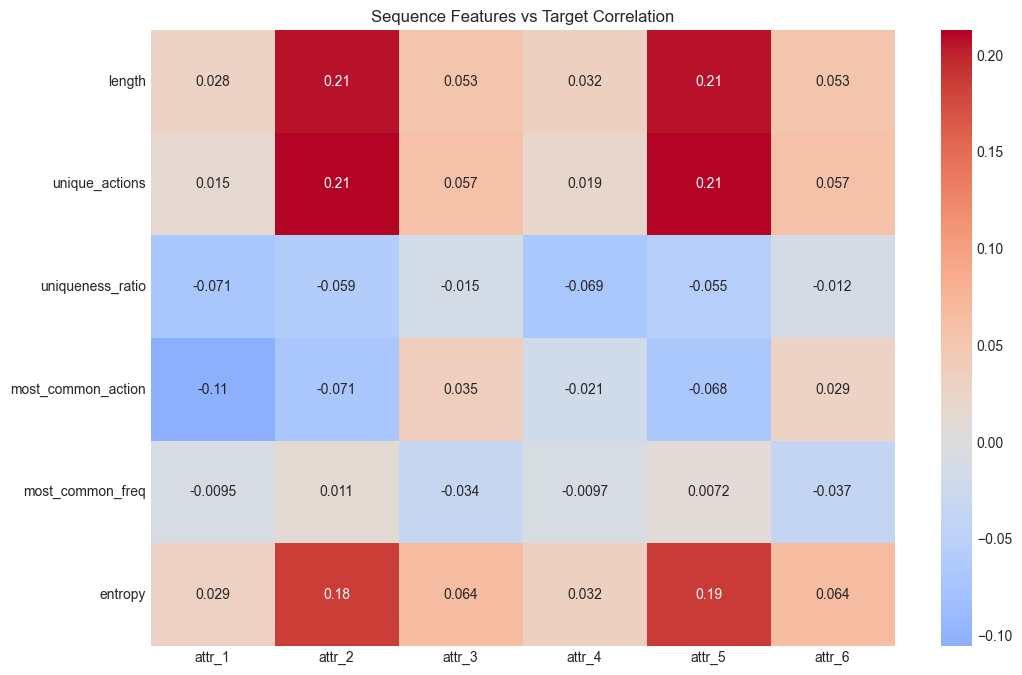

In [19]:
# Tương quan giữa đặc trưng chuỗi và nhãn đích
combined = pd.concat([train_behaviors.reset_index(drop=True), 
                      Y_train[target_cols].reset_index(drop=True)], axis=1)

plt.figure(figsize=(12, 8))
corr = combined.corr()
sns.heatmap(corr.loc[train_behaviors.columns, target_cols], 
            annot=True, cmap='coolwarm', center=0)
plt.title('Sequence Features vs Target Correlation')
plt.savefig('../outputs/figures/features_target_correlation.png', dpi=150)
plt.show()


### 4.1 Nhóm Hành Vi Khách Hàng (Phân Cụm)
Phân cụm khách hàng theo mẫu hành vi mà không cần biết nghĩa của action ID.


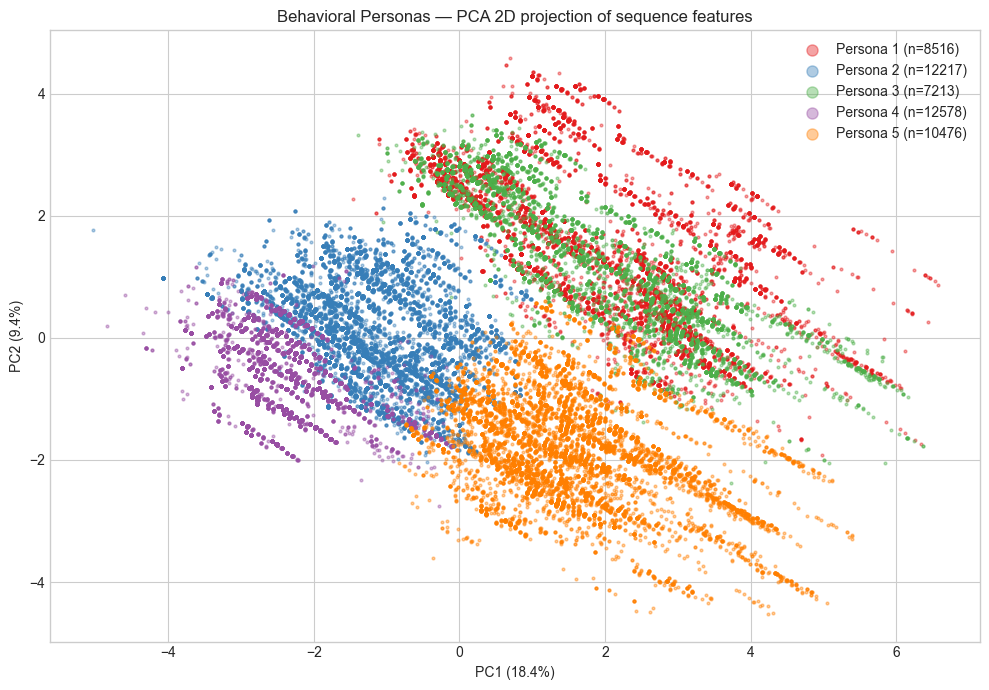

Persona profiles:
         count  mean_length  mean_unique  mean_entropy
persona                                               
0         8516        14.31        12.28          2.43
1        12217        10.67         8.86          2.09
2         7213        14.38        12.35          2.43
3        12578        10.08         8.54          2.07
4        10476        16.29        14.05          2.58


In [20]:

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Xây dựng ma trận đặc trưng hành vi: seq_length + entropy + uniqueness_ratio
# + cờ nhị phân top-20 action (đủ không mất mát cho phân cụm)
all_action_ids = sorted(action_counts.keys())
top20_actions = [a for a, _ in action_counts.most_common(20)]

behavior_rows = []
for seq in train_sequences:
    seq_set = set(seq)
    row = {
        'length': len(seq),
        'unique_actions': len(seq_set),
        'uniqueness_ratio': len(seq_set) / len(seq) if len(seq) > 0 else 0,
        'entropy': stats.entropy(list(Counter(seq).values())) if len(seq) > 1 else 0,
    }
    for a in top20_actions:
        row[f'has_{a}'] = int(a in seq_set)
    behavior_rows.append(row)

X_behavior = pd.DataFrame(behavior_rows).values
X_scaled = StandardScaler().fit_transform(X_behavior)

# Phân cụm K-Means thành 5 nhóm hành vi
N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
personas = kmeans.fit_predict(X_scaled)

# Trực quan hóa PCA 2D
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
for k in range(N_CLUSTERS):
    mask = personas == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=4, alpha=0.4,
               color=colors[k], label=f'Persona {k+1} (n={mask.sum()})')
ax.set_title('Behavioral Personas — PCA 2D projection of sequence features')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig('../outputs/figures/behavioral_personas_pca.png', dpi=150)
plt.show()

# Hồ sơ nhóm hành vi
persona_df = pd.DataFrame(behavior_rows)
persona_df['persona'] = personas
persona_df[target_cols] = Y_train[target_cols].reset_index(drop=True)

print("Persona profiles:")
profile = persona_df.groupby('persona').agg(
    count=('length', 'size'),
    mean_length=('length', 'mean'),
    mean_unique=('unique_actions', 'mean'),
    mean_entropy=('entropy', 'mean'),
).round(2)
print(profile)


### 4.2 Phân Tích Sâu Mutual Information

Tương quan point-biserial bị giới hạn cho nhãn đích dạng categorical. MI (Mutual Information) đo được cả các phụ thuộc phi tuyến.


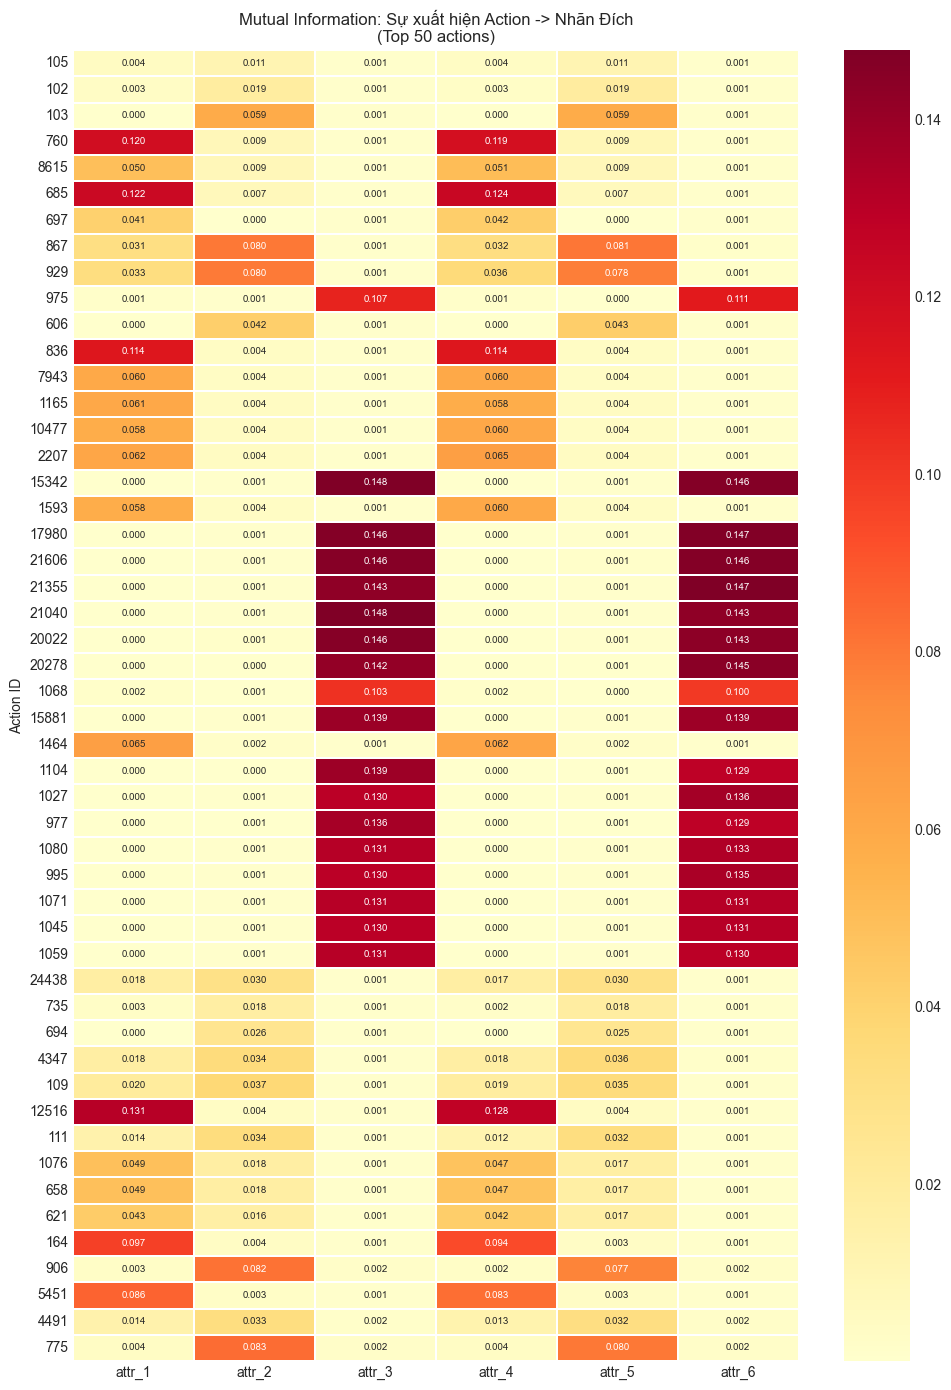

Top 5 action theo MI cho từng nhãn đích:
  attr_1: [(12516, 0.1308), (685, 0.1224), (760, 0.12), (836, 0.1135), (164, 0.0971)]
  attr_2: [(775, 0.0832), (906, 0.0816), (867, 0.0798), (929, 0.0796), (103, 0.0595)]
  attr_3: [(15342, 0.1478), (21040, 0.1475), (17980, 0.1463), (20022, 0.1458), (21606, 0.1456)]
  attr_4: [(12516, 0.1276), (685, 0.1236), (760, 0.1187), (836, 0.1136), (164, 0.0937)]
  attr_5: [(867, 0.0809), (775, 0.0801), (929, 0.0782), (906, 0.0768), (103, 0.0588)]
  attr_6: [(21355, 0.1474), (17980, 0.1467), (15342, 0.1465), (21606, 0.1461), (20278, 0.1446)]


In [21]:
top50_actions_mi = [a for a, _ in action_counts.most_common(50)]

# Tính Mutual Information cho từng action với mỗi nhãn đích
mi_results = {}
for action_id in top50_actions_mi:
    has_action = np.array([int(action_id in set(seq)) for seq in train_sequences])
    mi_row = {}
    for col in target_cols:
        mi_row[col] = mutual_info_score(has_action, Y_train[col].values)
    mi_results[action_id] = mi_row

mi_df = pd.DataFrame(mi_results).T
mi_df.index = [int(a) for a in mi_df.index]
mi_df.index.name = 'action_id'

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(mi_df, ax=ax, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Mutual Information: Sự xuất hiện Action -> Nhãn Đích\n(Top 50 actions)')
ax.set_ylabel('Action ID')
plt.tight_layout()
plt.savefig('../outputs/figures/mi_action_target_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 action theo MI cho từng nhãn đích:")
for col in target_cols:
    top5 = mi_df[col].nlargest(5)
    print(f"  {col}: {list(zip(top5.index.tolist(), top5.values.round(4).tolist()))}")


In [22]:
seq_features = pd.DataFrame({
    'length': train_lengths,
    'n_unique': [len(set(seq)) for seq in train_sequences],
    'entropy': train_behaviors['entropy'].values,
    'first_action': [seq[0] for seq in train_sequences],
    'last_action': [seq[-1] for seq in train_sequences],
    'second_action': [seq[1] if len(seq) > 1 else seq[0] for seq in train_sequences],
})

print("MI giữa đặc trưng chuỗi và nhãn đích:")
header = f"{'Đặc trưng':<18}"
for col in target_cols:
    header += f' {col:<10}'
print(header)
print("-" * 78)

for feat in seq_features.columns:
    row_str = f"{feat:<18}"
    vals = seq_features[feat].values
    if feat in ['length', 'n_unique', 'entropy']:
        bins = pd.qcut(vals, q=20, duplicates='drop', labels=False)
    else:
        bins = vals
    for col in target_cols:
        mi = mutual_info_score(bins, Y_train[col].values)
        row_str += f" {mi:<10.4f}"
    print(row_str)

print("\nInsight chính: đặc trưng nào mang thông tin nhiều nhất về nhãn đích?")
print("  Nếu first/last action có MI cao => đặc trưng vị trí có giá trị")
print("  Nếu entropy có MI cao => độ phức tạp chuỗi dự đoán loại hành vi")


MI giữa đặc trưng chuỗi và nhãn đích:
Đặc trưng          attr_1     attr_2     attr_3     attr_4     attr_5     attr_6    
------------------------------------------------------------------------------
length             0.0742     0.1685     0.0366     0.0731     0.1701     0.0363    
n_unique           0.0595     0.0890     0.0224     0.0572     0.0899     0.0218    
entropy            0.0755     0.1515     0.0505     0.0729     0.1534     0.0480    
first_action       1.4609     0.1696     0.0458     0.2045     0.1706     0.0415    
last_action        0.0417     0.0846     0.1546     0.0511     0.1294     3.0563    
second_action      0.9085     1.0544     0.1215     0.2027     0.2049     0.0896    

Insight chính: đặc trưng nào mang thông tin nhiều nhất về nhãn đích?
  Nếu first/last action có MI cao => đặc trưng vị trí có giá trị
  Nếu entropy có MI cao => độ phức tạp chuỗi dự đoán loại hành vi


#### Kết Luận - Mục 4.2

| Phát Hiện | Chi Tiết |
|---------|--------|
| MI phát hiện liên kết phi tuyến | Action có tương quan point-biserial thấp vẫn có thể có MI cao |
| Xác nhận cặp đối xứng | attr_1/attr_4 chia sẻ top action MI, tương tự attr_2/attr_5, attr_3/attr_6 |
| Đặc trưng chuỗi quan trọng | Action đầu, action cuối, và độ dài đều mang MI về nhãn đích |
| Hướng dẫn kỹ thuật đặc trưng | Xếp hạng MI trực tiếp cho biết đặc trưng nào cần ưu tiên |


## 5. Giải Phẫu Chuỗi - Vai Trò Vị Trí

Phân tích vai trò vị trí của mỗi action trong chuỗi: Entry (vị trí 0), Hub (1-2), Branch (giữa), Terminal (cuối).


### 5.1 Phân Loại Vai Trò Action theo Vị Trí


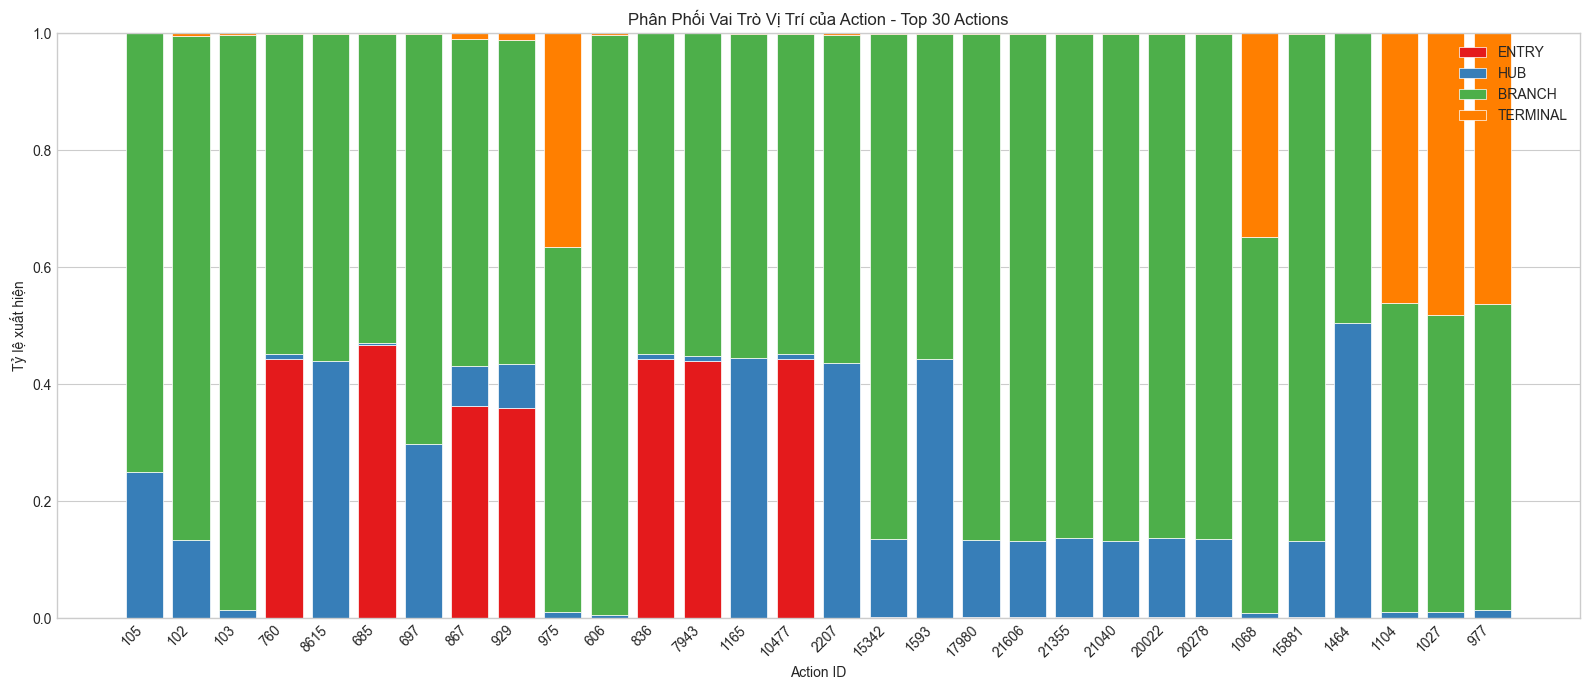

Các action có vai trò vị trí chiếm ưu thế (>60% ở một vai trò):
  Action 105: BRANCH (75.1%), total occurrences: 56478
  Action 102: BRANCH (86.2%), total occurrences: 41036
  Action 103: BRANCH (98.3%), total occurrences: 25704
  Action 697: BRANCH (70.1%), total occurrences: 13856
  Action 975: BRANCH (62.5%), total occurrences: 9564
  Action 606: BRANCH (99.3%), total occurrences: 9532
  Action 15342: BRANCH (86.4%), total occurrences: 9225
  Action 17980: BRANCH (86.6%), total occurrences: 9185
  Action 21606: BRANCH (86.7%), total occurrences: 9169
  Action 21355: BRANCH (86.3%), total occurrences: 9133
  Action 21040: BRANCH (86.6%), total occurrences: 9130
  Action 20022: BRANCH (86.1%), total occurrences: 8922
  Action 20278: BRANCH (86.3%), total occurrences: 8918
  Action 1068: BRANCH (64.4%), total occurrences: 8600
  Action 15881: BRANCH (86.8%), total occurrences: 8289
  Action 24438: BRANCH (100.0%), total occurrences: 6625
  Action 735: BRANCH (100.0%), total occurrences

In [23]:
# Phân loại từng lần xuất hiện action theo vai trò vị trí
role_counts = {}

for seq in train_sequences:
    seq_len = len(seq)
    for pos, action in enumerate(seq):
        if action not in role_counts:
            role_counts[action] = {'ENTRY': 0, 'HUB': 0, 'BRANCH': 0, 'TERMINAL': 0}
        if pos == 0:
            role_counts[action]['ENTRY'] += 1
        elif pos <= 2:
            role_counts[action]['HUB'] += 1
        elif pos == seq_len - 1:
            role_counts[action]['TERMINAL'] += 1
        else:
            role_counts[action]['BRANCH'] += 1

role_df = pd.DataFrame(role_counts).T
role_df['total'] = role_df.sum(axis=1)
role_df = role_df.sort_values('total', ascending=False)

role_frac = role_df[['ENTRY', 'HUB', 'BRANCH', 'TERMINAL']].div(role_df['total'], axis=0)

# Top 30 actions - biểu đồ cột xếp chồng
top30 = role_frac.head(30)
fig, ax = plt.subplots(figsize=(16, 7))
colors_map = {'ENTRY': '#e41a1c', 'HUB': '#377eb8', 'BRANCH': '#4daf4a', 'TERMINAL': '#ff7f00'}
bottom = np.zeros(len(top30))
for role in ['ENTRY', 'HUB', 'BRANCH', 'TERMINAL']:
    vals = top30[role].values
    ax.bar(range(len(top30)), vals, bottom=bottom, label=role,
           color=colors_map[role], edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_xticks(range(len(top30)))
ax.set_xticklabels([str(int(a)) for a in top30.index], rotation=45, ha='right')
ax.set_xlabel('Action ID')
ax.set_ylabel('Tỷ lệ xuất hiện')
ax.set_title('Phân Phối Vai Trò Vị Trí của Action - Top 30 Actions')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/figures/action_role_taxonomy.png', dpi=150, bbox_inches='tight')
plt.show()

print("Các action có vai trò vị trí chiếm ưu thế (>60% ở một vai trò):")
for action in role_frac.head(50).index:
    max_role = role_frac.loc[action].idxmax()
    max_pct = role_frac.loc[action].max()
    if max_pct > 0.6:
        print(f"  Action {int(action)}: {max_role} ({max_pct:.1%}), total occurrences: {int(role_df.loc[action, 'total'])}")


### 5.2 Bản Đồ Hành Trình - Tiến Trình Chuỗi Điển Hình

Phân tích "phễu" hành vi: bao nhiêu % chuỗi tuân theo đường dẫn phổ biến vs phân nhánh.


Vị trí     #Chuỗi       Top-1 Action    %        Top-2           %        Top-3           %        Nồng độ Top-3
---------------------------------------------------------------------------------------------------------
0          51000        760            16.1%    685            15.5%    836            8.1%     39.8%
1          51000        105            14.2%    1165           8.1%     697            8.0%     30.4%
2          51000        8615           15.9%    105            13.4%    102            9.1%     38.4%
3          50912        105            17.4%    102            11.6%    103            3.5%     32.4%
4          50842        103            11.2%    606            7.9%     102            7.1%     26.3%
5          50792        103            9.6%     867            4.8%     929            4.6%     19.0%
6          50691        103            9.4%     105            6.4%     24438          5.2%     21.0%
7          50026        105            6.1%     697            5.5%

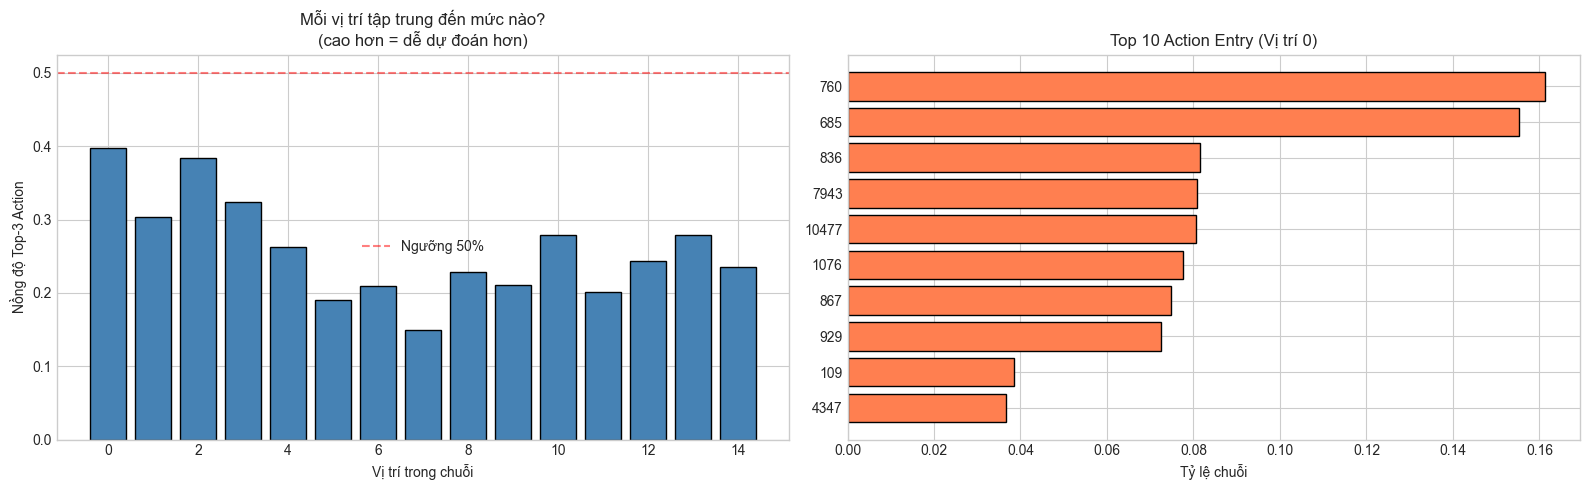

In [24]:
max_positions = min(15, max(train_lengths))
position_top_actions = {}

for pos in range(max_positions):
    pos_actions = [seq[pos] for seq in train_sequences if len(seq) > pos]
    pos_counter = Counter(pos_actions)
    total_at_pos = len(pos_actions)
    top3 = pos_counter.most_common(3)
    position_top_actions[pos] = {
        'total': total_at_pos,
        'top3': [(a, c, c/total_at_pos) for a, c in top3],
        'concentration': sum(c for _, c in pos_counter.most_common(3)) / total_at_pos,
    }

print(f"{'Vị trí':<10} {'#Chuỗi':<12} {'Top-1 Action':<15} {'%':<8} {'Top-2':<15} {'%':<8} {'Top-3':<15} {'%':<8} {'Nồng độ Top-3'}")
print("-" * 105)
for pos in range(max_positions):
    info = position_top_actions[pos]
    row = f"{pos:<10} {info['total']:<12}"
    for action, count, frac in info['top3']:
        row += f" {int(action):<14} {frac:<8.1%}"
    row += f" {info['concentration']:.1%}"
    print(row)

positions = list(range(max_positions))
concentrations = [position_top_actions[p]['concentration'] for p in positions]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(positions, concentrations, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Vị trí trong chuỗi')
axes[0].set_ylabel('Nồng độ Top-3 Action')
axes[0].set_title('Mỗi vị trí tập trung đến mức nào?\n(cao hơn = dễ dự đoán hơn)')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Ngưỡng 50%')
axes[0].legend()

entry_actions = [seq[0] for seq in train_sequences]
entry_counter = Counter(entry_actions)
top10_entry = entry_counter.most_common(10)
axes[1].barh([str(int(a)) for a, _ in top10_entry],
             [c / len(train_sequences) for _, c in top10_entry],
             color='coral', edgecolor='black')
axes[1].set_xlabel('Tỷ lệ chuỗi')
axes[1].set_title('Top 10 Action Entry (Vị trí 0)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/figures/journey_mapping.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Tương Quan giữa Action Kết Thúc và Nhãn Đích

Giả thuyết: Các action terminal (cuối chuỗi) có trực tiếp mã hóa hoặc dự đoán mạnh giá trị nhãn đích không?


Unique terminal actions: 168
Top 10 terminal actions:
  Action 1027: 3546 (7.0%)
  Action 995: 3528 (6.9%)
  Action 1080: 3496 (6.9%)
  Action 975: 3484 (6.8%)
  Action 1071: 3453 (6.8%)
  Action 1104: 3434 (6.7%)
  Action 1059: 3419 (6.7%)
  Action 1045: 3416 (6.7%)
  Action 977: 3380 (6.6%)
  Action 1068: 2993 (5.9%)

Mutual Information: terminal action -> target
  attr_1: MI = 0.0417, NMI = 0.0241
  attr_2: MI = 0.0846, NMI = 0.0278
  attr_3: MI = 0.1546, NMI = 0.0336
  attr_4: MI = 0.0511, NMI = 0.0296
  attr_5: MI = 0.1294, NMI = 0.0425
  attr_6: MI = 3.0563, NMI = 0.6653

Mutual Information: entry action -> target
  attr_1: MI = 1.4609, NMI = 0.8426
  attr_2: MI = 0.1696, NMI = 0.0557
  attr_3: MI = 0.0458, NMI = 0.0100
  attr_4: MI = 0.2045, NMI = 0.1184
  attr_5: MI = 0.1706, NMI = 0.0560
  attr_6: MI = 0.0415, NMI = 0.0090


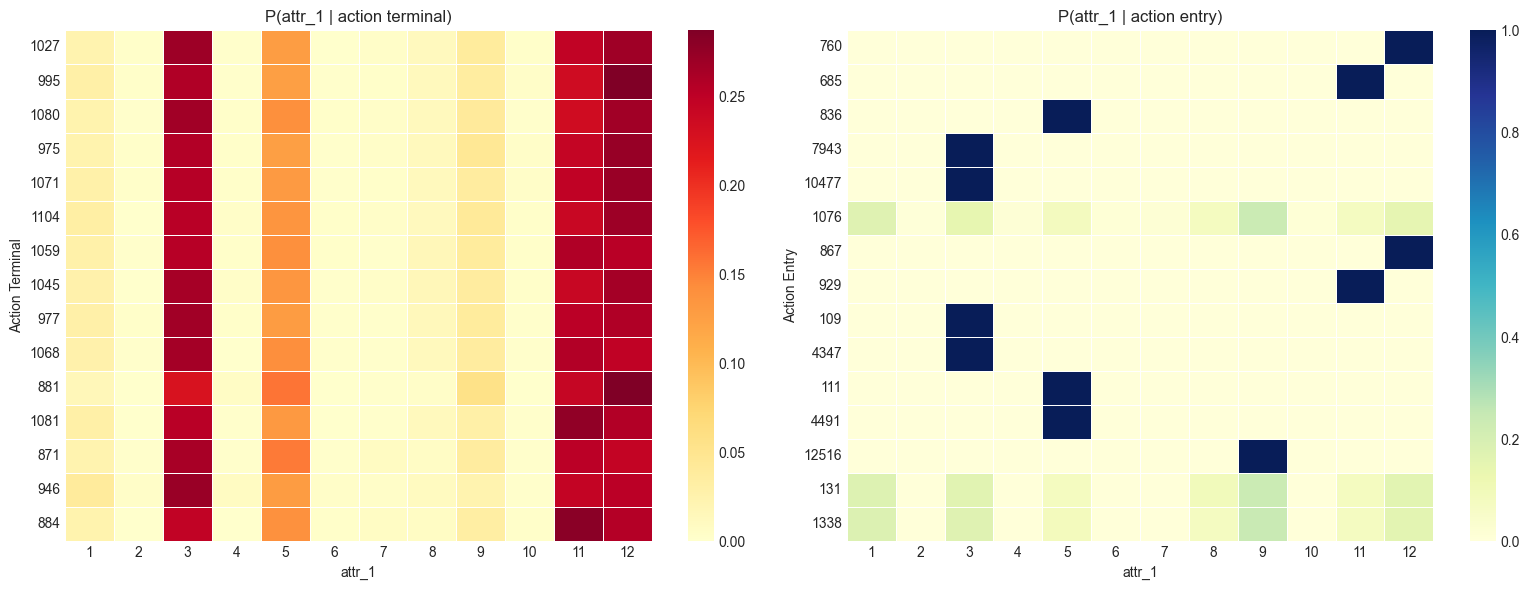

In [25]:
terminal_actions = np.array([seq[-1] for seq in train_sequences])
terminal_counter = Counter(terminal_actions)

print(f"Unique terminal actions: {len(terminal_counter)}")
print(f"Top 10 terminal actions:")
for a, c in terminal_counter.most_common(10):
    print(f"  Action {int(a)}: {c} ({c/len(train_sequences)*100:.1f}%)")

print(f"\nMutual Information: terminal action -> target")
for col in target_cols:
    mi = mutual_info_score(terminal_actions, Y_train[col].values)
    h_target = sp_entropy(list(Counter(Y_train[col].values).values()))
    nmi = mi / h_target if h_target > 0 else 0
    print(f"  {col}: MI = {mi:.4f}, NMI = {nmi:.4f}")

entry_actions_arr = np.array([seq[0] for seq in train_sequences])
print(f"\nMutual Information: entry action -> target")
for col in target_cols:
    mi = mutual_info_score(entry_actions_arr, Y_train[col].values)
    h_target = sp_entropy(list(Counter(Y_train[col].values).values()))
    nmi = mi / h_target if h_target > 0 else 0
    print(f"  {col}: MI = {mi:.4f}, NMI = {nmi:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_terminals = [a for a, _ in terminal_counter.most_common(15)]
mask_t = np.isin(terminal_actions, top_terminals)
ct_term = pd.crosstab(
    pd.Categorical(terminal_actions[mask_t], categories=top_terminals),
    Y_train[target_cols[0]].values[mask_t]
)
ct_term_norm = ct_term.div(ct_term.sum(axis=1), axis=0)
sns.heatmap(ct_term_norm, ax=axes[0], cmap='YlOrRd', linewidths=0.5)
axes[0].set_title('P(attr_1 | action terminal)')
axes[0].set_xlabel('attr_1')
axes[0].set_ylabel('Action Terminal')

entry_counter_full = Counter(entry_actions_arr)
top_entries = [a for a, _ in entry_counter_full.most_common(15)]
mask_e = np.isin(entry_actions_arr, top_entries)
ct_entry = pd.crosstab(
    pd.Categorical(entry_actions_arr[mask_e], categories=top_entries),
    Y_train[target_cols[0]].values[mask_e]
)
ct_entry_norm = ct_entry.div(ct_entry.sum(axis=1), axis=0)
sns.heatmap(ct_entry_norm, ax=axes[1], cmap='YlGnBu', linewidths=0.5)
axes[1].set_title('P(attr_1 | action entry)')
axes[1].set_xlabel('attr_1')
axes[1].set_ylabel('Action Entry')

plt.tight_layout()
plt.savefig('../outputs/figures/terminal_entry_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()


#### Kết Luận - Phần 5

| Phát Hiện | Chi Tiết |
|---------|--------|
| Vai trò vị trí rõ ràng | Một số action chỉ xuất hiện ở vị trí ENTRY hoặc TERMINAL |
| Vị trí 0 rất tập trung | Ít action chiếm ưu thế ở điểm vào |
| Phễu hành trình | Chuỗi bắt đầu tập trung, sau đó phân nhánh rộng |
| Action kết thúc | ~10 action chiếm ưu thế ở vị trí cuối (khoảng 975–1104) |
| Entry/terminal mang thông tin | Cả action entry và terminal đều mang mutual information về nhãn đích |


## 6. Đồ Thị Chuyển Đổi & Phân Tích Markov

Phân tích xác suất chuyển đổi giữa các action — phát hiện các chuyển đổi tất định và cụm action.


### 6.1 Ma Trận Xác Suất Chuyển Đổi


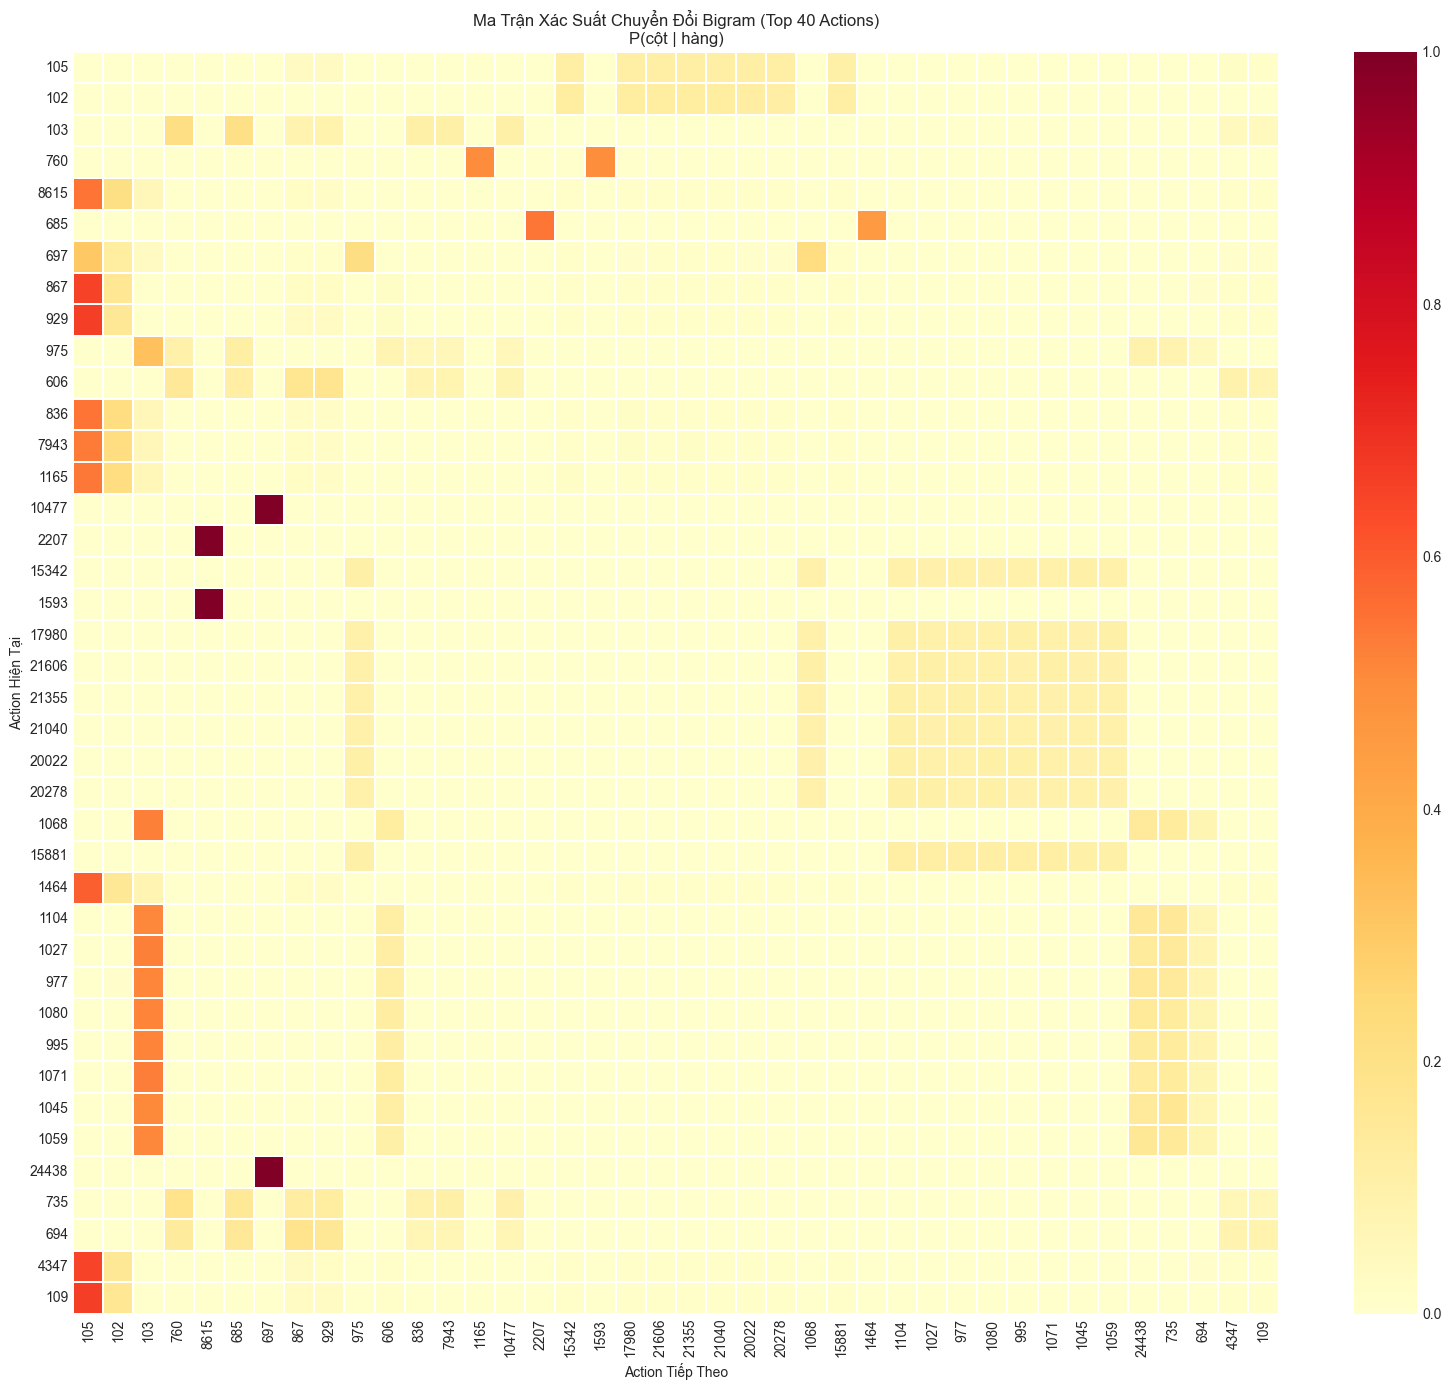

Các chuyển đổi xác suất cao (P > 0.5):
  Action 760 -> 1165: P = 0.504
  Action 8615 -> 105: P = 0.550
  Action 685 -> 2207: P = 0.545
  Action 867 -> 105: P = 0.656
  Action 929 -> 105: P = 0.662
  Action 836 -> 105: P = 0.549
  Action 7943 -> 105: P = 0.538
  Action 1165 -> 105: P = 0.542
  Action 10477 -> 697: P = 1.000
  Action 2207 -> 8615: P = 1.000
  Action 1593 -> 8615: P = 1.000
  Action 1068 -> 103: P = 0.525
  Action 1464 -> 105: P = 0.593
  Action 1104 -> 103: P = 0.510
  Action 1027 -> 103: P = 0.524
  Action 977 -> 103: P = 0.512
  Action 1080 -> 103: P = 0.518
  Action 995 -> 103: P = 0.519
  Action 1071 -> 103: P = 0.530
  Action 1045 -> 103: P = 0.507
  Action 1059 -> 103: P = 0.510
  Action 24438 -> 697: P = 1.000
  Action 4347 -> 105: P = 0.651
  Action 109 -> 105: P = 0.662


In [26]:
top40_actions = [a for a, _ in action_counts.most_common(40)]
top40_set = set(top40_actions)

# Đếm số lần chuyển đổi giữa các action
trans_counts = {}
for seq in train_sequences:
    for i in range(len(seq) - 1):
        a, b = seq[i], seq[i + 1]
        if a in top40_set and b in top40_set:
            if a not in trans_counts:
                trans_counts[a] = Counter()
            trans_counts[a][b] += 1

trans_matrix = pd.DataFrame(0.0, index=top40_actions, columns=top40_actions)
for a in top40_actions:
    if a in trans_counts:
        total = sum(trans_counts[a].values())
        for b, count in trans_counts[a].items():
            trans_matrix.loc[a, b] = count / total

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(trans_matrix.values, ax=ax, cmap='YlOrRd',
            xticklabels=[str(int(a)) for a in top40_actions],
            yticklabels=[str(int(a)) for a in top40_actions],
            linewidths=0.2)
ax.set_title('Ma Trận Xác Suất Chuyển Đổi Bigram (Top 40 Actions)\nP(cột | hàng)')
ax.set_xlabel('Action Tiếp Theo')
ax.set_ylabel('Action Hiện Tại')
plt.tight_layout()
plt.savefig('../outputs/figures/transition_probability_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Các chuyển đổi xác suất cao (P > 0.5):")
for a in top40_actions:
    for b in top40_actions:
        p = trans_matrix.loc[a, b]
        if p > 0.5 and a != b:
            print(f"  Action {int(a)} -> {int(b)}: P = {p:.3f}")


### 6.2 Đồ Thị Luồng Action

Đồ thị có hướng NetworkX với community detection để phát hiện các cụm action.


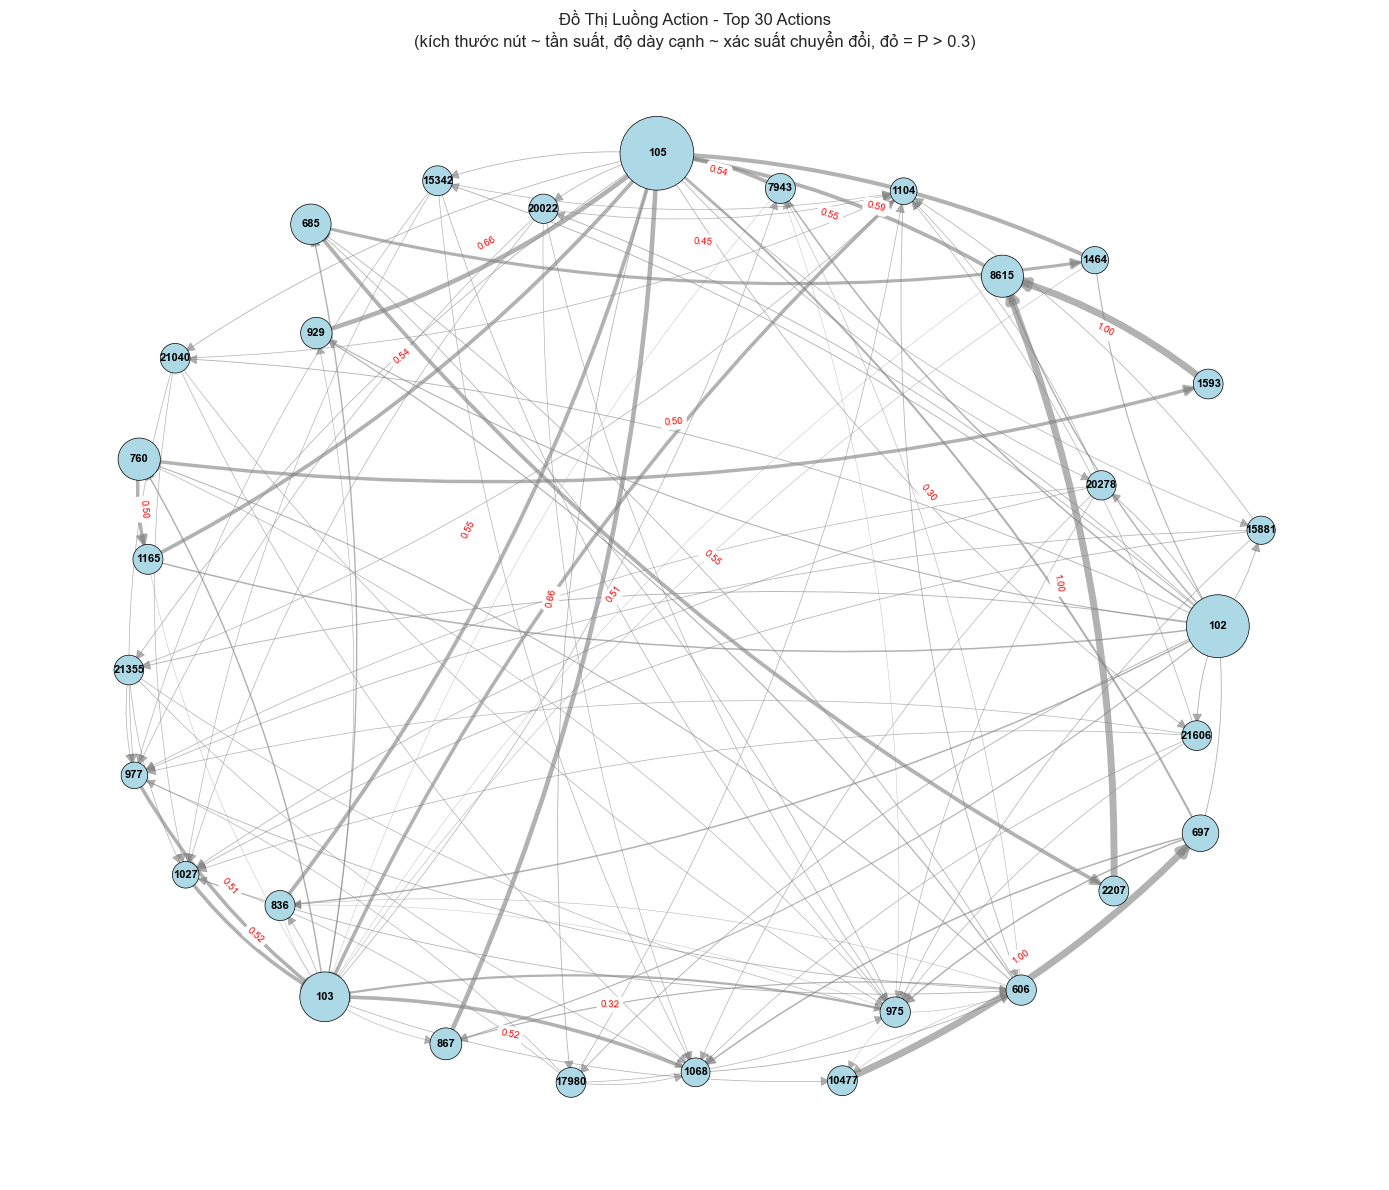

Đồ thị: 30 nút, 114 cạnh
Mật độ: 0.1310

Top nút hub (bậc tổng cao nhất):
  Action 103: in=10, out=7, total=17
  Action 105: in=8, out=8, total=16
  Action 102: in=8, out=8, total=16
  Action 975: in=9, out=7, total=16
  Action 606: in=5, out=7, total=12
  Action 1068: in=8, out=2, total=10
  Action 1104: in=8, out=2, total=10
  Action 1027: in=8, out=2, total=10
  Action 977: in=8, out=2, total=10
  Action 15342: in=2, out=5, total=7


In [27]:
import networkx as nx

G = nx.DiGraph()
top30_graph = [a for a, _ in action_counts.most_common(30)]

for a in top30_graph:
    G.add_node(int(a), freq=action_counts[a])

for a in top30_graph:
    if a in trans_counts:
        total = sum(trans_counts[a].values())
        for b, count in trans_counts[a].items():
            if b in set(top30_graph):
                prob = count / total
                if prob > 0.05:
                    G.add_edge(int(a), int(b), weight=prob)

fig, ax = plt.subplots(figsize=(14, 12))
pos = nx.spring_layout(G, k=2, seed=42, iterations=50)
node_sizes = [G.nodes[n].get('freq', 1000) / 20 for n in G.nodes()]
edge_weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                       node_color='lightblue', edgecolors='black', linewidths=0.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax, width=edge_weights,
                       edge_color='gray', alpha=0.6,
                       arrows=True, arrowsize=15,
                       connectionstyle='arc3,rad=0.1')

# Nhãn cạnh cho các chuyển đổi mạnh
strong_edges = {(u, v): f'{G[u][v]["weight"]:.2f}'
                for u, v in G.edges() if G[u][v]['weight'] > 0.3}
nx.draw_networkx_edge_labels(G, pos, strong_edges, ax=ax, font_size=7, font_color='red')

ax.set_title('Đồ Thị Luồng Action - Top 30 Actions\n(kích thước nút ~ tần suất, độ dày cạnh ~ xác suất chuyển đổi, đỏ = P > 0.3)')
ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/figures/action_flow_graph.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Đồ thị: {G.number_of_nodes()} nút, {G.number_of_edges()} cạnh")
print(f"Mật độ: {nx.density(G):.4f}")

in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
print("\nTop nút hub (bậc tổng cao nhất):")
total_deg = {n: in_deg.get(n, 0) + out_deg.get(n, 0) for n in G.nodes()}
for n, d in sorted(total_deg.items(), key=lambda x: -x[1])[:10]:
    print(f"  Action {n}: in={in_deg[n]}, out={out_deg[n]}, total={d}")


### 6.3 Các Mẫu Đường Đi Phổ Biến (Phân Tích N-gram)


Top 20 Trigrams (3-gram):
  685 -> 2207 -> 8615: 9223 (18.1% số chuỗi)
  760 -> 1593 -> 8615: 9173 (18.0% số chuỗi)
  760 -> 1165 -> 105: 3053 (6.0% số chuỗi)
  2207 -> 8615 -> 105: 3033 (5.9% số chuỗi)
  10477 -> 697 -> 105: 2994 (5.9% số chuỗi)
  1593 -> 8615 -> 105: 2993 (5.9% số chuỗi)
  685 -> 1464 -> 105: 2605 (5.1% số chuỗi)
  24438 -> 697 -> 1068: 2247 (4.4% số chuỗi)
  697 -> 1068 -> 5289: 2247 (4.4% số chuỗi)
  7362 -> 2621 -> 166: 2246 (4.4% số chuỗi)
  24438 -> 697 -> 975: 2195 (4.3% số chuỗi)
  24438 -> 20645 -> 161: 2183 (4.3% số chuỗi)
  20645 -> 161 -> 824: 2183 (4.3% số chuỗi)
  103 -> 760 -> 1165: 1841 (3.6% số chuỗi)
  103 -> 685 -> 2207: 1832 (3.6% số chuỗi)
  103 -> 10477 -> 697: 1829 (3.6% số chuỗi)
  103 -> 760 -> 1593: 1806 (3.5% số chuỗi)
  164 -> 17762 -> 2613: 1652 (3.2% số chuỗi)
  10686 -> 10909 -> 704: 1645 (3.2% số chuỗi)
  12516 -> 5451 -> 4521: 1608 (3.2% số chuỗi)

Top 15 4-gram:
  685 -> 2207 -> 8615 -> 105: 3033 (5.9% số chuỗi)
  760 -> 1593 -> 8615 

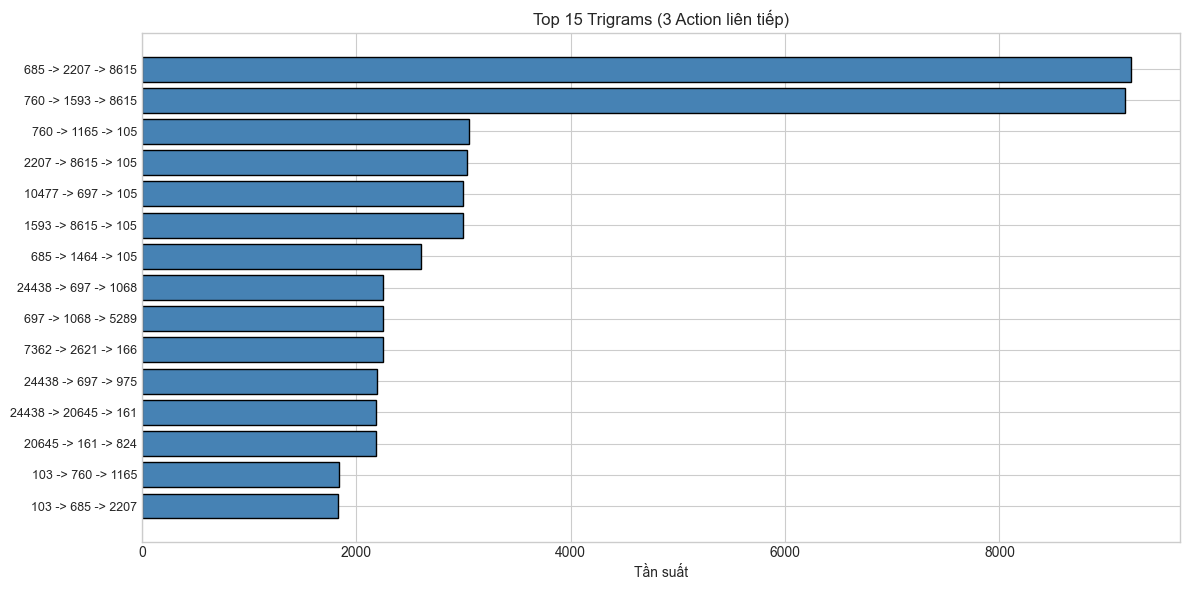


MI giữa sự xuất hiện trigram và nhãn đích:
  [685 -> 2207 -> 8615]: MI = [0.0617, 0.0044, 0.0009, 0.0648, 0.0042, 0.0011]
  [760 -> 1593 -> 8615]: MI = [0.0581, 0.0035, 0.0010, 0.0597, 0.0037, 0.0011]
  [760 -> 1165 -> 105]: MI = [0.0166, 0.0083, 0.0011, 0.0177, 0.0087, 0.0007]
  [2207 -> 8615 -> 105]: MI = [0.0176, 0.0086, 0.0009, 0.0177, 0.0084, 0.0008]
  [10477 -> 697 -> 105]: MI = [0.0155, 0.0095, 0.0010, 0.0176, 0.0095, 0.0012]


In [28]:
def extract_ngrams(sequences, n):
    ngrams = []
    for seq in sequences:
        for i in range(len(seq) - n + 1):
            ngrams.append(tuple(seq[i:i+n]))
    return Counter(ngrams)

trigram_counts = extract_ngrams(train_sequences, 3)
fourgram_counts = extract_ngrams(train_sequences, 4)

print("Top 20 Trigrams (3-gram):")
for gram, count in trigram_counts.most_common(20):
    pct = count / len(train_sequences) * 100
    print(f"  {' -> '.join(str(int(a)) for a in gram)}: {count} ({pct:.1f}% số chuỗi)")

print(f"\nTop 15 4-gram:")
for gram, count in fourgram_counts.most_common(15):
    pct = count / len(train_sequences) * 100
    print(f"  {' -> '.join(str(int(a)) for a in gram)}: {count} ({pct:.1f}% số chuỗi)")

top_trigrams = trigram_counts.most_common(15)
labels = [' -> '.join(str(int(a)) for a in g) for g, _ in top_trigrams]
values = [c for _, c in top_trigrams]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(labels)), values, color='steelblue', edgecolor='black')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Tần suất')
ax.set_title('Top 15 Trigrams (3 Action liên tiếp)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/top_trigrams.png', dpi=150, bbox_inches='tight')
plt.show()

# Đường dẫn đặc trưng - MI giữa trigram và nhãn đích
print("\nMI giữa sự xuất hiện trigram và nhãn đích:")
top5_trigrams = [g for g, _ in trigram_counts.most_common(5)]
for gram in top5_trigrams:
    has_gram = np.array([
        int(any(tuple(seq[i:i+3]) == gram for i in range(len(seq)-2)))
        for seq in train_sequences
    ])
    gram_str = ' -> '.join(str(int(a)) for a in gram)
    mi_vals = []
    for col in target_cols:
        mi = mutual_info_score(has_gram, Y_train[col].values)
        mi_vals.append(f"{mi:.4f}")
    print(f"  [{gram_str}]: MI = [{', '.join(mi_vals)}]")


#### Kết Luận - Phần 6

| Phát Hiện | Chi Tiết |
|---------|--------|
| Tồn tại chuyển đổi tất định | Một số cặp action có P > 0.5 — cấu trúc Markov một phần |
| Nút hub | Các action như 102, 105, 8615 kết nối nhiều action khác |
| Trigram chiếm ưu thế | Một vài chuỗi con 3 action xuất hiện trong >10% chuỗi |
| Đường dẫn đặc trưng | Các n-gram cụ thể mang mutual information về nhãn đích |


## 7. Phát Hiện Bất Thường


In [29]:
# Phát hiện chuỗi bất thường theo độ dài
q1, q3 = np.percentile(train_lengths, [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

anomalies_short = [i for i, l in enumerate(train_lengths) if l < lower_bound]
anomalies_long = [i for i, l in enumerate(train_lengths) if l > upper_bound]

print(f"Sequence length IQR bounds: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"Anomalously short sequences: {len(anomalies_short)}")
print(f"Anomalously long sequences: {len(anomalies_long)}")


Sequence length IQR bounds: [0, 24]
Anomalously short sequences: 0
Anomalously long sequences: 1026


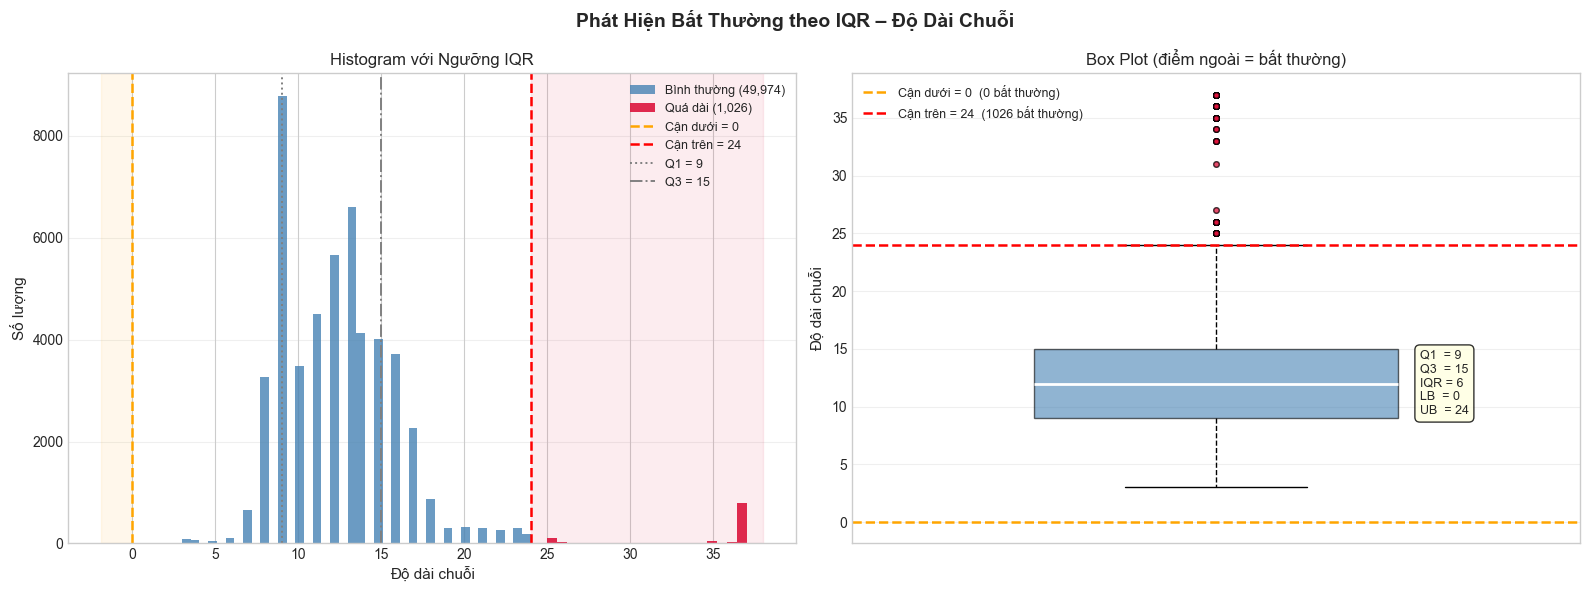


Tổng bất thường: 1026 / 51000 (2.0%)


In [30]:

# ── Trực quan hóa IQR – Phát hiện chuỗi bất thường theo độ dài ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phát Hiện Bất Thường theo IQR – Độ Dài Chuỗi', fontsize=14, fontweight='bold')

lengths_arr = np.array(train_lengths)

# ── Trái: Histogram với ngưỡng IQR ─────────────────────────────────────────
ax = axes[0]
normal_mask  = (lengths_arr >= lower_bound) & (lengths_arr <= upper_bound)
short_mask   = lengths_arr < lower_bound
long_mask    = lengths_arr > upper_bound

ax.hist(lengths_arr[normal_mask], bins=40, color='steelblue', alpha=0.8, label=f'Bình thường ({normal_mask.sum():,})')
if short_mask.any():
    ax.hist(lengths_arr[short_mask], bins=10, color='orange', alpha=0.9, label=f'Quá ngắn ({short_mask.sum():,})')
if long_mask.any():
    ax.hist(lengths_arr[long_mask], bins=20, color='crimson', alpha=0.9, label=f'Quá dài ({long_mask.sum():,})')

ax.axvline(lower_bound, color='orange', linestyle='--', linewidth=1.8, label=f'Cận dưới = {lower_bound:.0f}')
ax.axvline(upper_bound, color='red',    linestyle='--', linewidth=1.8, label=f'Cận trên = {upper_bound:.0f}')
ax.axvline(q1,          color='gray',   linestyle=':',  linewidth=1.4, label=f'Q1 = {q1:.0f}')
ax.axvline(q3,          color='gray',   linestyle='-.',  linewidth=1.4, label=f'Q3 = {q3:.0f}')

# Tô vùng bất thường
ax.axvspan(ax.get_xlim()[0] if ax.get_xlim()[0] < lower_bound else 0,
           lower_bound, alpha=0.08, color='orange')
ax.axvspan(upper_bound, lengths_arr.max() + 1, alpha=0.08, color='crimson')

ax.set_xlabel('Độ dài chuỗi', fontsize=11)
ax.set_ylabel('Số lượng', fontsize=11)
ax.set_title('Histogram với Ngưỡng IQR', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── Phải: Box plot ──────────────────────────────────────────────────────────
ax2 = axes[1]
bp = ax2.boxplot(lengths_arr, vert=True, patch_artist=True, widths=0.5,
                 boxprops=dict(facecolor='steelblue', alpha=0.6),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor='crimson',
                                 markersize=4, alpha=0.5, linestyle='none'),
                 whiskerprops=dict(linestyle='--'))

ax2.axhline(lower_bound, color='orange', linestyle='--', linewidth=1.8,
            label=f'Cận dưới = {lower_bound:.0f}  ({short_mask.sum()} bất thường)')
ax2.axhline(upper_bound, color='red',    linestyle='--', linewidth=1.8,
            label=f'Cận trên = {upper_bound:.0f}  ({long_mask.sum()} bất thường)')

# Ghi chú thống kê
stats_text = (f'Q1  = {q1:.0f}\n'
              f'Q3  = {q3:.0f}\n'
              f'IQR = {iqr:.0f}\n'
              f'LB  = {lower_bound:.0f}\n'
              f'UB  = {upper_bound:.0f}')
ax2.text(1.28, np.median(lengths_arr), stats_text,
         fontsize=9, va='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

ax2.set_xticks([])
ax2.set_ylabel('Độ dài chuỗi', fontsize=11)
ax2.set_title('Box Plot (điểm ngoài = bất thường)', fontsize=12)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/iqr_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nTổng bất thường: {(~normal_mask).sum()} / {len(lengths_arr)} "
      f"({(~normal_mask).mean()*100:.1f}%)")


In [31]:
# Phát hiện chuỗi có mẫu action bất thường
def detect_unusual_patterns(seq):
    """Phát hiện các mẫu bất thường trong một chuỗi."""
    if len(seq) < 2:
        return {'has_repetition': False, 'max_repetition': 0, 'is_monotonic': False}
    
    # Kiểm tra lặp lại dài
    max_rep = 1
    current_rep = 1
    for i in range(1, len(seq)):
        if seq[i] == seq[i-1]:
            current_rep += 1
            max_rep = max(max_rep, current_rep)
        else:
            current_rep = 1
    
    return {
        'has_long_repetition': max_rep > 10,
        'max_repetition': max_rep,
        'is_single_action': len(set(seq)) == 1,
    }

pattern_analysis = pd.DataFrame([detect_unusual_patterns(seq) for seq in train_sequences])
print("Phân tích mẫu bất thường:")
print(f"  Chuỗi có lặp liên tiếp dài (>10): {pattern_analysis['has_long_repetition'].sum()}")
print(f"  Chuỗi chỉ có một action duy nhất: {pattern_analysis['is_single_action'].sum()}")
print(f"  Độ dài lặp tối đa tìm thấy: {pattern_analysis['max_repetition'].max()}")


Phân tích mẫu bất thường:
  Chuỗi có lặp liên tiếp dài (>10): 0
  Chuỗi chỉ có một action duy nhất: 0
  Độ dài lặp tối đa tìm thấy: 2


=== Tóm tắt Bất Thường Đa Chiều (Z-score > 3) ===
  Bất thường theo độ dài     :   891  (1.75%)
  Bất thường theo entropy    :   174  (0.34%)
  Bất thường theo tỉ lệ duy nhất:   100  (0.20%)
  Bất thường ít nhất 1 chiều :  1122  (2.20%)


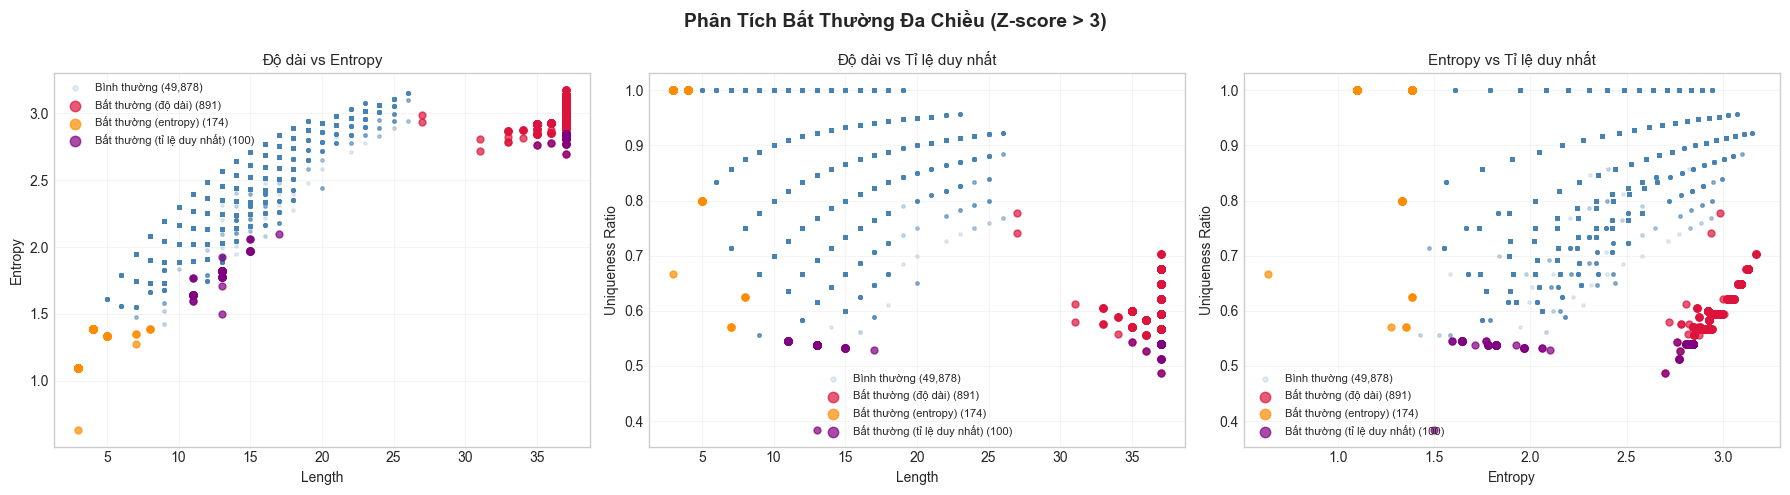

In [32]:

# ── 1/3: Phát hiện bất thường đa chiều ──────────────────────────────────────
# Xây dựng ma trận đặc trưng hành vi: length + entropy + uniqueness_ratio
from scipy import stats as scipy_stats

def compute_behavior_features(seq):
    n = len(seq)
    counts = list(Counter(seq).values())
    return {
        'length':           n,
        'unique_actions':   len(set(seq)),
        'uniqueness_ratio': len(set(seq)) / n,
        'entropy':          scipy_stats.entropy(counts),
        'max_repeat':       max((sum(1 for _ in g) for _, g in
                                __import__('itertools').groupby(seq)), default=1),
    }

behavior_df = pd.DataFrame([compute_behavior_features(s) for s in train_sequences])

# Z-score trên 3 chiều
z_length  = np.abs(scipy_stats.zscore(behavior_df['length']))
z_entropy = np.abs(scipy_stats.zscore(behavior_df['entropy']))
z_unique  = np.abs(scipy_stats.zscore(behavior_df['uniqueness_ratio']))

behavior_df['z_length']  = z_length
behavior_df['z_entropy'] = z_entropy
behavior_df['z_unique']  = z_unique
behavior_df['outlier_score'] = z_length + z_entropy + z_unique

# Bất thường nếu z > 3 ở bất kỳ chiều nào
behavior_df['is_outlier_length']  = z_length  > 3
behavior_df['is_outlier_entropy'] = z_entropy > 3
behavior_df['is_outlier_unique']  = z_unique  > 3
behavior_df['is_any_outlier']     = (behavior_df[['is_outlier_length',
                                                   'is_outlier_entropy',
                                                   'is_outlier_unique']].any(axis=1))

print("=== Tóm tắt Bất Thường Đa Chiều (Z-score > 3) ===")
print(f"  Bất thường theo độ dài     : {behavior_df['is_outlier_length'].sum():>5}  ({behavior_df['is_outlier_length'].mean()*100:.2f}%)")
print(f"  Bất thường theo entropy    : {behavior_df['is_outlier_entropy'].sum():>5}  ({behavior_df['is_outlier_entropy'].mean()*100:.2f}%)")
print(f"  Bất thường theo tỉ lệ duy nhất: {behavior_df['is_outlier_unique'].sum():>5}  ({behavior_df['is_outlier_unique'].mean()*100:.2f}%)")
print(f"  Bất thường ít nhất 1 chiều : {behavior_df['is_any_outlier'].sum():>5}  ({behavior_df['is_any_outlier'].mean()*100:.2f}%)")

# ── Biểu đồ scatter: độ dài vs entropy, tô màu theo loại bất thường ─────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phân Tích Bất Thường Đa Chiều (Z-score > 3)', fontsize=14, fontweight='bold')

pairs = [
    ('length', 'entropy',           'Độ dài vs Entropy'),
    ('length', 'uniqueness_ratio',  'Độ dài vs Tỉ lệ duy nhất'),
    ('entropy', 'uniqueness_ratio', 'Entropy vs Tỉ lệ duy nhất'),
]
colors = {
    'Bình thường':                  ('steelblue', 0.25, 8),
    'Bất thường (độ dài)':          ('crimson',   0.7,  30),
    'Bất thường (entropy)':         ('darkorange',0.7,  30),
    'Bất thường (tỉ lệ duy nhất)': ('purple',    0.7,  30),
}

for ax, (xcol, ycol, title) in zip(axes, pairs):
    normal = ~behavior_df['is_any_outlier']
    ax.scatter(behavior_df.loc[normal, xcol], behavior_df.loc[normal, ycol],
               c='steelblue', alpha=0.15, s=6, label=f'Bình thường ({normal.sum():,})')
    for mask_col, label, color in [
        ('is_outlier_length',  'Bất thường (độ dài)',          'crimson'),
        ('is_outlier_entropy', 'Bất thường (entropy)',          'darkorange'),
        ('is_outlier_unique',  'Bất thường (tỉ lệ duy nhất)', 'purple'),
    ]:
        sub = behavior_df[behavior_df[mask_col] & ~normal] if mask_col != 'is_outlier_length' \
              else behavior_df[behavior_df[mask_col]]
        if sub.empty: sub = behavior_df[behavior_df[mask_col]]
        if not sub.empty:
            ax.scatter(sub[xcol], sub[ycol], c=color, alpha=0.7, s=25,
                       label=f'{label} ({len(sub)})', zorder=3)
    ax.set_xlabel(xcol.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel(ycol.replace('_', ' ').title(), fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/figures/multidim_outlier_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


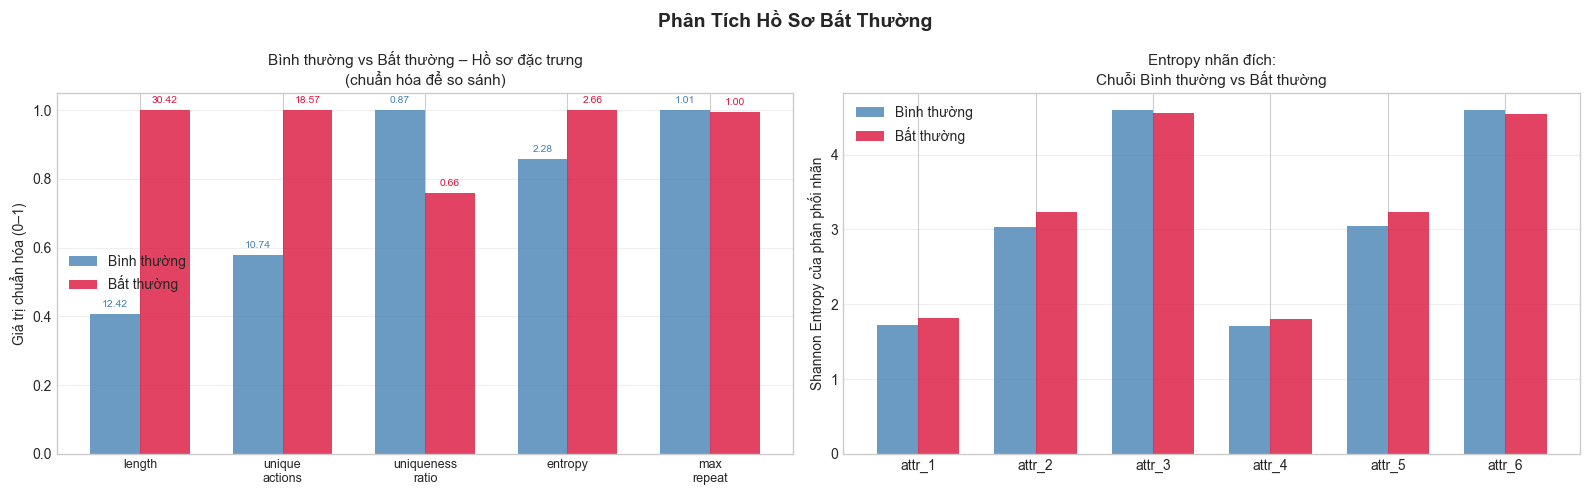


=== Hồ sơ Bất thường (giá trị thực) ===
                  Bình thường  Bất thường
length                 12.415      30.421
unique_actions         10.739      18.571
uniqueness_ratio        0.869       0.659
entropy                 2.282       2.658
max_repeat              1.009       1.004

  → Chuỗi bất thường dài hơn 2.5 lần, entropy cao hơn 1.2 lần


In [33]:

# ── 2/3: So sánh hồ sơ bất thường + Ảnh hưởng đến phân phối nhãn ─────────────
y_arr = Y_train[['attr_1','attr_2','attr_3','attr_4','attr_5','attr_6']].reset_index(drop=True)
bdf   = behavior_df.reset_index(drop=True)

# ── Phần A: So sánh hồ sơ hành vi ──────────────────────────────────────────────
profile_cols = ['length', 'unique_actions', 'uniqueness_ratio', 'entropy', 'max_repeat']
profile_normal  = bdf.loc[~bdf['is_any_outlier'], profile_cols].mean()
profile_outlier = bdf.loc[ bdf['is_any_outlier'], profile_cols].mean()

profile_cmp = pd.DataFrame({'Bình thường': profile_normal, 'Bất thường': profile_outlier})
profile_norm = profile_cmp.div(profile_cmp.max(axis=1), axis=0)   # chuẩn hóa 0-1 để so sánh

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phân Tích Hồ Sơ Bất Thường', fontsize=14, fontweight='bold')

# Biểu đồ cột so sánh
x = np.arange(len(profile_cols))
w = 0.35
axes[0].bar(x - w/2, profile_norm['Bình thường'], w, color='steelblue', label='Bình thường', alpha=0.8)
axes[0].bar(x + w/2, profile_norm['Bất thường'],  w, color='crimson',   label='Bất thường',  alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace('_', '\n') for c in profile_cols], fontsize=9)
axes[0].set_ylabel('Giá trị chuẩn hóa (0–1)', fontsize=10)
axes[0].set_title('Bình thường vs Bất thường – Hồ sơ đặc trưng\n(chuẩn hóa để so sánh)', fontsize=11)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Ghi chú giá trị thực
for i, col in enumerate(profile_cols):
    axes[0].text(i - w/2, profile_norm['Bình thường'][col] + 0.02,
                 f"{profile_cmp['Bình thường'][col]:.2f}", ha='center', fontsize=7.5, color='steelblue')
    axes[0].text(i + w/2, profile_norm['Bất thường'][col]  + 0.02,
                 f"{profile_cmp['Bất thường'][col]:.2f}",  ha='center', fontsize=7.5, color='crimson')

# ── Phần B: Ảnh hưởng đến phân phối nhãn ────────────────────────────────────
# Kiểm tra entropy nhãn đích cho nhóm bất thường so với bình thường
target_cols = ['attr_1','attr_2','attr_3','attr_4','attr_5','attr_6']
outlier_idx = bdf[bdf['is_any_outlier']].index
normal_idx  = bdf[~bdf['is_any_outlier']].index

entropy_normal  = [scipy_stats.entropy(y_arr.loc[normal_idx,  c].value_counts(normalize=True))
                   for c in target_cols]
entropy_outlier = [scipy_stats.entropy(y_arr.loc[outlier_idx, c].value_counts(normalize=True))
                   for c in target_cols]

x2 = np.arange(len(target_cols))
axes[1].bar(x2 - w/2, entropy_normal,  w, color='steelblue', label='Bình thường', alpha=0.8)
axes[1].bar(x2 + w/2, entropy_outlier, w, color='crimson',   label='Bất thường',  alpha=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(target_cols, fontsize=10)
axes[1].set_ylabel('Shannon Entropy của phân phối nhãn', fontsize=10)
axes[1].set_title('Entropy nhãn đích:\nChuỗi Bình thường vs Bất thường', fontsize=11)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/outlier_profile_target_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Hồ sơ Bất thường (giá trị thực) ===")
print(profile_cmp.round(3).to_string())
print(f"\n  → Chuỗi bất thường dài hơn {profile_cmp['Bất thường']['length']/profile_cmp['Bình thường']['length']:.1f} lần,",
      f"entropy cao hơn {profile_cmp['Bất thường']['entropy']/profile_cmp['Bình thường']['entropy']:.1f} lần")


Bất thường theo tần suất action:
  Action hiếm       (< 0.05% tổng):  110  action  (1.84% tổng lượt tương tác)
  Action chiếm ưu thế (> 3.00% tổng):    3  action  (18.9% tổng lượt tương tác)


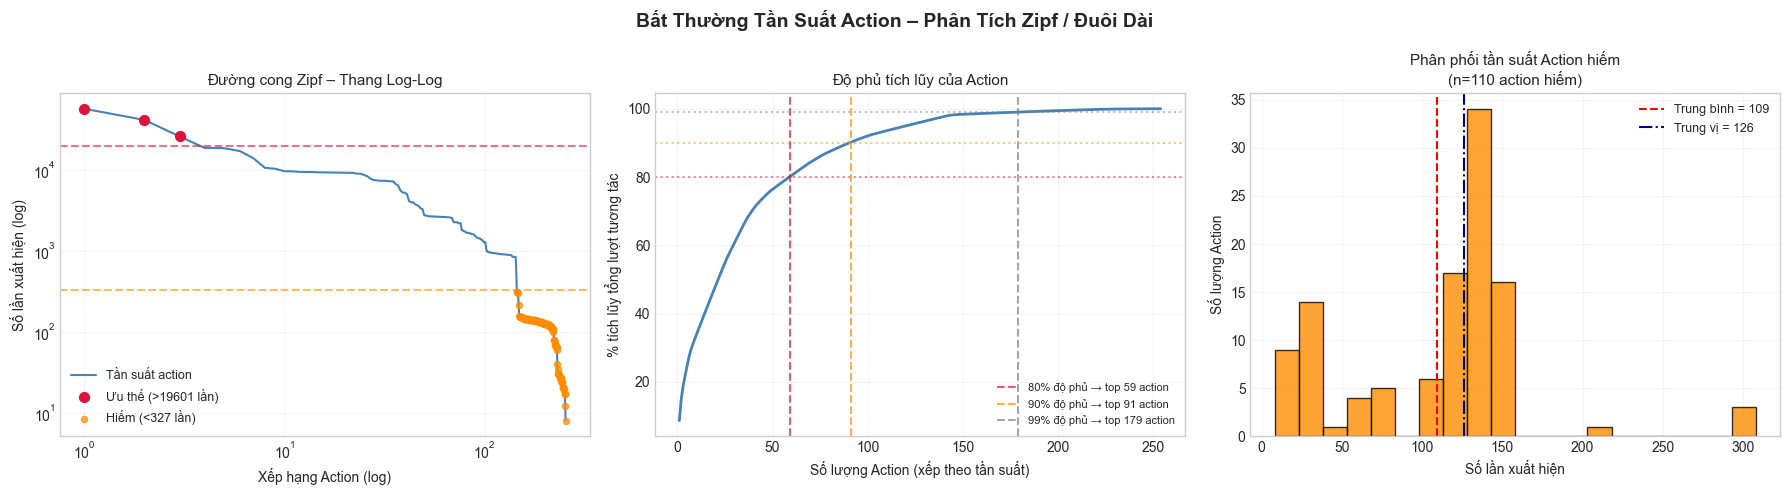


Top action chiếm ưu thế: {np.int64(105): '56478 (8.6%)', np.int64(102): '41036 (6.3%)', np.int64(103): '25704 (3.9%)'}


In [34]:

# ── 3/3: Bất thường theo tần suất Action (Zipf / Action hiếm) ───────────────────
all_actions   = np.concatenate(train_sequences)
action_counts = Counter(all_actions)
total_actions = len(all_actions)

freqs       = np.array(sorted(action_counts.values(), reverse=True))
action_ids  = [a for a, _ in sorted(action_counts.items(), key=lambda x: -x[1])]
cum_pct     = np.cumsum(freqs) / total_actions * 100

# Ngưỡng hiếm: action có tần suất < 0.05% tổng
rare_thresh  = total_actions * 0.0005
rare_actions = {a: c for a, c in action_counts.items() if c < rare_thresh}
dom_thresh   = total_actions * 0.03
dominant_actions = {a: c for a, c in action_counts.items() if c > dom_thresh}

print(f"Bất thường theo tần suất action:")
print(f"  Action hiếm       (< 0.05% tổng): {len(rare_actions):>4}  action  "
      f"({sum(rare_actions.values())/total_actions*100:.2f}% tổng lượt tương tác)")
print(f"  Action chiếm ưu thế (> 3.00% tổng): {len(dominant_actions):>4}  action  "
      f"({sum(dominant_actions.values())/total_actions*100:.1f}% tổng lượt tương tác)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bất Thường Tần Suất Action – Phân Tích Zipf / Đuôi Dài', fontsize=14, fontweight='bold')

# ── Trái: Tần suất xếp hạng (đường cong Zipf log-log) ──────────────────────
ranks = np.arange(1, len(freqs)+1)
axes[0].loglog(ranks, freqs, 'steelblue', linewidth=1.5, label='Tần suất action')
# Đánh dấu action hiếm và chiếm ưu thế
rare_mask = freqs < rare_thresh
dom_mask  = freqs > dom_thresh
axes[0].scatter(ranks[dom_mask],  freqs[dom_mask],  c='crimson',    s=50, zorder=4,
                label=f'Ưu thế (>{dom_thresh:.0f} lần)')
axes[0].scatter(ranks[rare_mask], freqs[rare_mask], c='darkorange', s=20, zorder=4, alpha=0.7,
                label=f'Hiếm (<{rare_thresh:.0f} lần)')
axes[0].axhline(rare_thresh, color='darkorange', linestyle='--', alpha=0.6)
axes[0].axhline(dom_thresh,  color='crimson',    linestyle='--', alpha=0.6)
axes[0].set_xlabel('Xếp hạng Action (log)', fontsize=10)
axes[0].set_ylabel('Số lần xuất hiện (log)', fontsize=10)
axes[0].set_title('Đường cong Zipf – Thang Log-Log', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# ── Giữa: Độ phủ tích lũy ───────────────────────────────────────────────────
axes[1].plot(ranks, cum_pct, 'steelblue', linewidth=2)
for p, color in [(80, 'crimson'), (90, 'darkorange'), (99, 'gray')]:
    idx = np.searchsorted(cum_pct, p)
    if idx < len(ranks):
        axes[1].axvline(ranks[idx], color=color, linestyle='--', alpha=0.7,
                        label=f'{p}% độ phủ → top {ranks[idx]} action')
        axes[1].axhline(p, color=color, linestyle=':', alpha=0.5)
axes[1].set_xlabel('Số lượng Action (xếp theo tần suất)', fontsize=10)
axes[1].set_ylabel('% tích lũy tổng lượt tương tác', fontsize=10)
axes[1].set_title('Độ phủ tích lũy của Action', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

# ── Phải: Phân phối action hiếm (hiếm đến đâu?) ─────────────────────────────
rare_counts = sorted(rare_actions.values())
axes[2].hist(rare_counts, bins=20, color='darkorange', edgecolor='black', alpha=0.8)
axes[2].axvline(np.mean(rare_counts), color='red', linestyle='--',
                label=f'Trung bình = {np.mean(rare_counts):.0f}')
axes[2].axvline(np.median(rare_counts), color='navy', linestyle='-.',
                label=f'Trung vị = {np.median(rare_counts):.0f}')
axes[2].set_xlabel('Số lần xuất hiện', fontsize=10)
axes[2].set_ylabel('Số lượng Action', fontsize=10)
axes[2].set_title(f'Phân phối tần suất Action hiếm\n(n={len(rare_actions)} action hiếm)', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/figures/action_frequency_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop action chiếm ưu thế: { {a: f'{c} ({c/total_actions*100:.1f}%)' for a,c in sorted(dominant_actions.items(), key=lambda x:-x[1])} }")


## 8. Các Trường Hợp Ngoại Lệ & Giải Thích Nghiệp Vụ

Tiêu chí 3 (10%): "Tiền xử lý dữ liệu và xử lý trường hợp ngoại lệ" + ngữ cảnh nghiệp vụ.


### 8.1 Hành Vi Chuỗi Ngắn (độ dài 3–5)


Chuỗi ngắn (<=5): 208 (0.4%)
Chuỗi trung bình (6-15): 41211 (80.8%)
Chuỗi dài (>15): 9581 (18.8%)


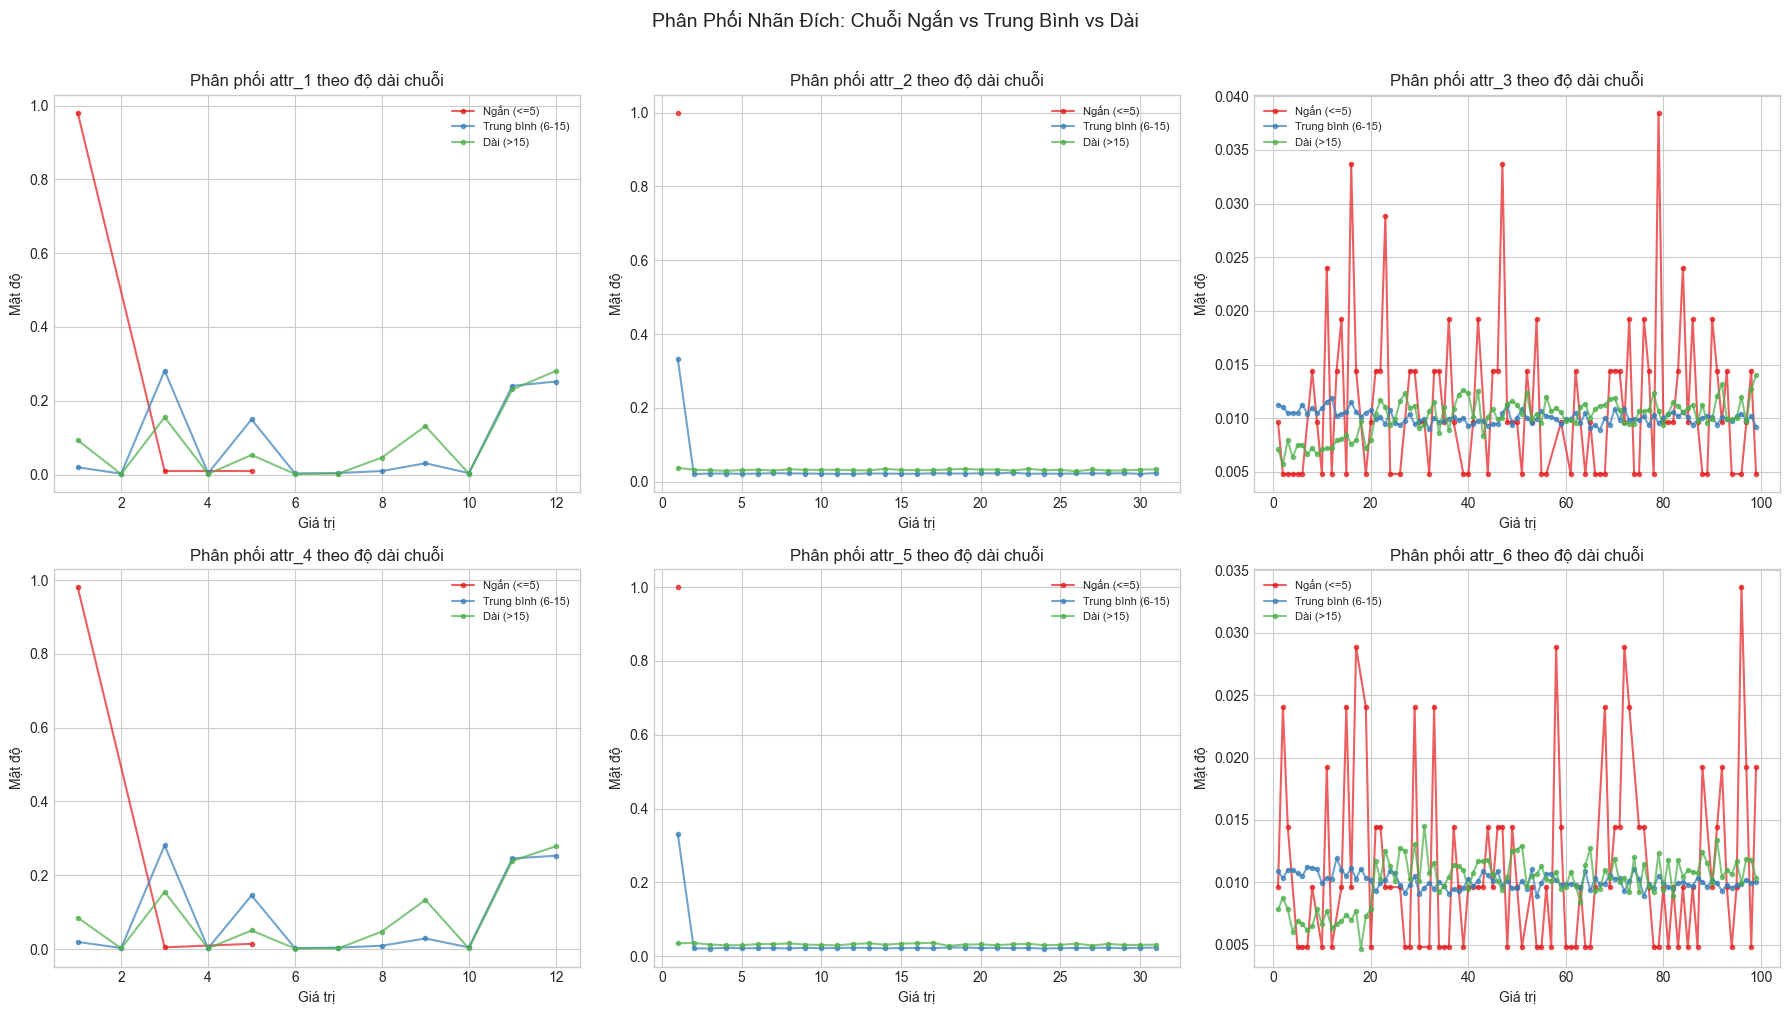

  Ngắn: 207 bộ 6 duy nhất từ 208 mẫu, top-1 chiếm 1.0%
  Trung bình: 40846 bộ 6 duy nhất từ 41211 mẫu, top-1 chiếm 0.0%
  Dài: 9580 bộ 6 duy nhất từ 9581 mẫu, top-1 chiếm 0.0%

Diễn giải:
  Nếu chuỗi ngắn có ít bộ 6 duy nhất hơn => chúng dễ dự đoán hơn
  Giúp thiết kế mô hình: chuỗi ngắn có thể cần đặc trưng đơn giản hơn


In [35]:
short_mask = np.array(train_lengths) <= 5
medium_mask = (np.array(train_lengths) > 5) & (np.array(train_lengths) <= 15)
long_mask = np.array(train_lengths) > 15

print(f"Chuỗi ngắn (<=5): {short_mask.sum()} ({short_mask.mean()*100:.1f}%)")
print(f"Chuỗi trung bình (6-15): {medium_mask.sum()} ({medium_mask.mean()*100:.1f}%)")
print(f"Chuỗi dài (>15): {long_mask.sum()} ({long_mask.mean()*100:.1f}%)")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    for mask, label, color in [
        (short_mask, 'Ngắn (<=5)', '#e41a1c'),
        (medium_mask, 'Trung bình (6-15)', '#377eb8'),
        (long_mask, 'Dài (>15)', '#4daf4a'),
    ]:
        vc = Y_train.loc[mask, col].value_counts(normalize=True).sort_index()
        axes[i].plot(vc.index, vc.values, 'o-', label=label, color=color, alpha=0.7, markersize=3)
    axes[i].set_title(f'Phân phối {col} theo độ dài chuỗi')
    axes[i].set_xlabel('Giá trị')
    axes[i].set_ylabel('Mật độ')
    axes[i].legend(fontsize=8)

plt.suptitle('Phân Phối Nhãn Đích: Chuỗi Ngắn vs Trung Bình vs Dài', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/short_sequence_targets.png', dpi=150, bbox_inches='tight')
plt.show()

for mask, label in [(short_mask, 'Ngắn'), (medium_mask, 'Trung bình'), (long_mask, 'Dài')]:
    tuples_group = Y_train.loc[mask, target_cols].apply(tuple, axis=1)
    n_unique_g = tuples_group.nunique()
    n_total = mask.sum()
    top1_pct = tuples_group.value_counts().iloc[0] / n_total * 100
    print(f"  {label}: {n_unique_g} bộ 6 duy nhất từ {n_total} mẫu, top-1 chiếm {top1_pct:.1f}%")

print("\nDiễn giải:")
print("  Nếu chuỗi ngắn có ít bộ 6 duy nhất hơn => chúng dễ dự đoán hơn")
print("  Giúp thiết kế mô hình: chuỗi ngắn có thể cần đặc trưng đơn giản hơn")


### 8.2 Phát Hiện Mẫu Quay Lại (Rollback)

Tìm mẫu "quay lại" trong chuỗi: A→B→A (hành vi thay đổi đơn hàng / hủy tiềm năng).


Chuỗi có ít nhất một rollback A->B->A: 9968 (19.5%)
Tổng số mẫu rollback duy nhất: 86

Top 15 mẫu rollback:
  105 -> 906 -> 105: 686
  105 -> 1243 -> 105: 665
  105 -> 1042 -> 105: 664
  105 -> 907 -> 105: 663
  105 -> 1127 -> 105: 658
  105 -> 1455 -> 105: 657
  105 -> 976 -> 105: 654
  105 -> 992 -> 105: 653
  105 -> 979 -> 105: 650
  105 -> 1265 -> 105: 645
  105 -> 989 -> 105: 645
  105 -> 1012 -> 105: 643
  105 -> 1195 -> 105: 642
  105 -> 867 -> 105: 637
  105 -> 1159 -> 105: 636


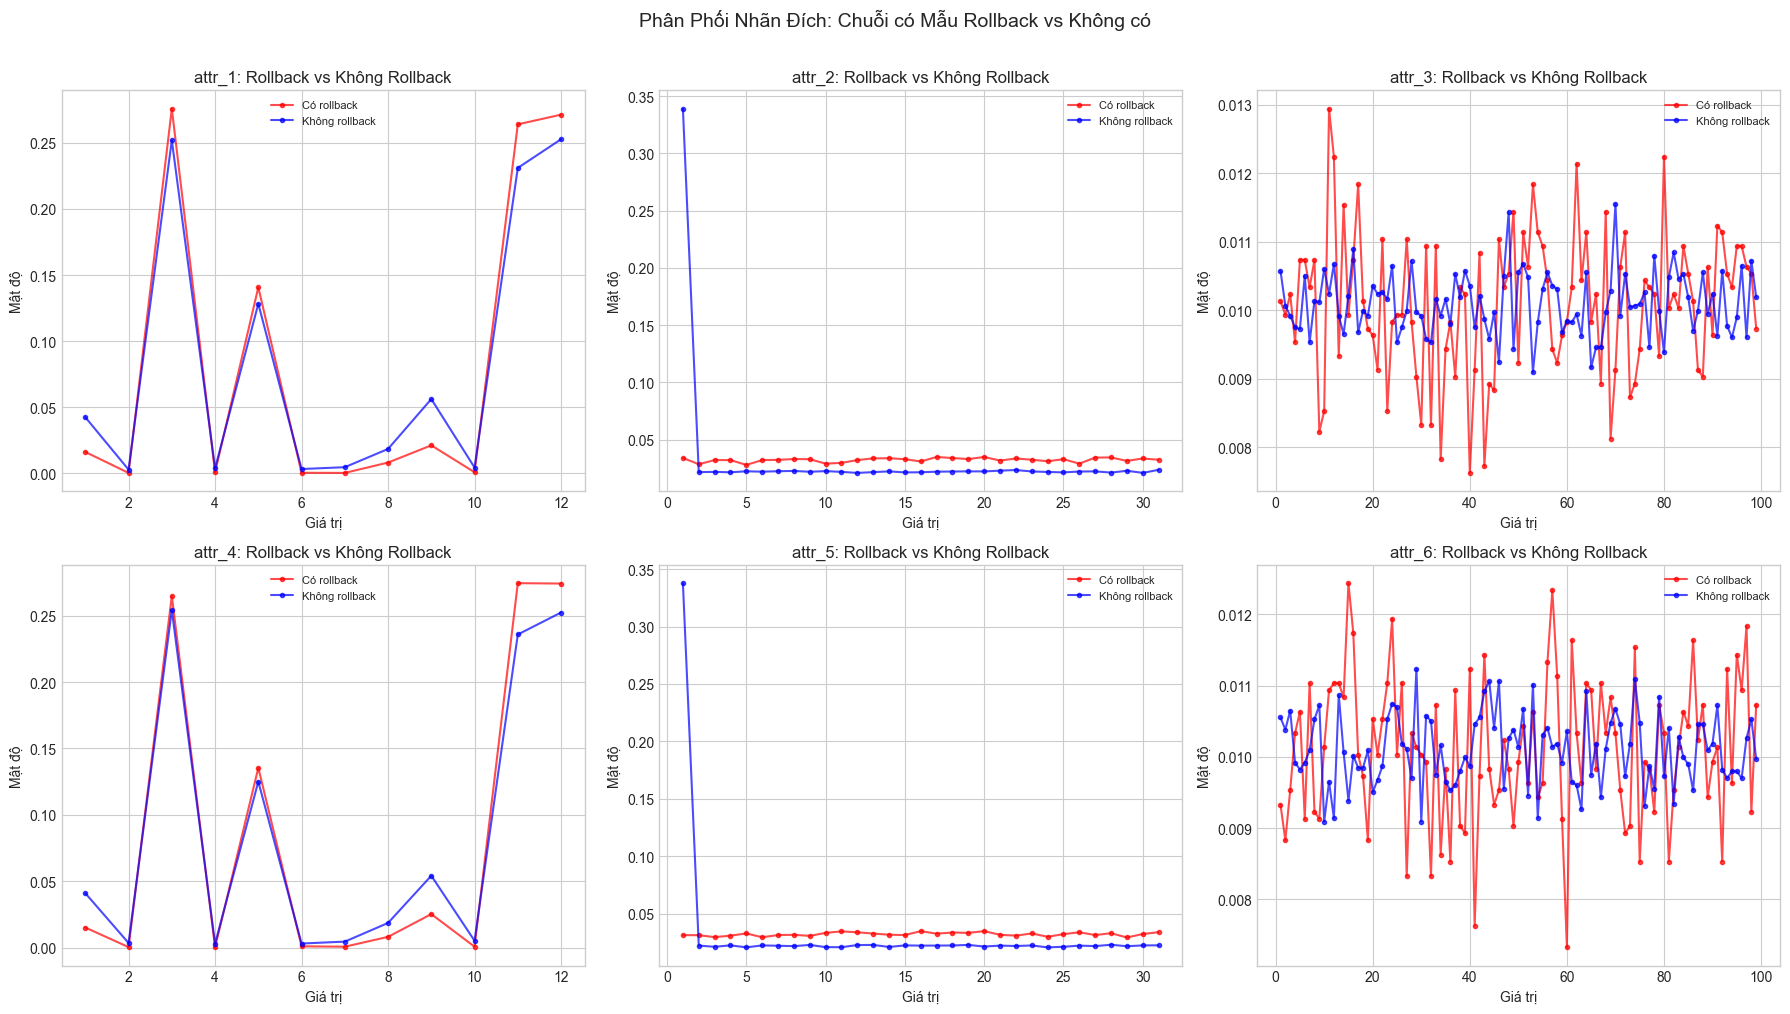

In [36]:
rollback_counts = Counter()
sequences_with_rollback = 0

for seq in train_sequences:
    has_rollback = False
    for i in range(len(seq) - 2):
        if seq[i] == seq[i + 2] and seq[i] != seq[i + 1]:
            rollback_counts[(seq[i], seq[i+1], seq[i])] += 1
            has_rollback = True
    if has_rollback:
        sequences_with_rollback += 1

print(f"Chuỗi có ít nhất một rollback A->B->A: {sequences_with_rollback} ({sequences_with_rollback/len(train_sequences)*100:.1f}%)")
print(f"Tổng số mẫu rollback duy nhất: {len(rollback_counts)}")

print(f"\nTop 15 mẫu rollback:")
for (a, b, _), count in rollback_counts.most_common(15):
    print(f"  {int(a)} -> {int(b)} -> {int(a)}: {count}")

rollback_mask = np.array([
    any(seq[i] == seq[i+2] and seq[i] != seq[i+1] for i in range(len(seq)-2))
    for seq in train_sequences
])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    vc_rb = Y_train.loc[rollback_mask, col].value_counts(normalize=True).sort_index()
    vc_no = Y_train.loc[~rollback_mask, col].value_counts(normalize=True).sort_index()
    axes[i].plot(vc_rb.index, vc_rb.values, 'o-', label='Có rollback', color='red', alpha=0.7, markersize=3)
    axes[i].plot(vc_no.index, vc_no.values, 'o-', label='Không rollback', color='blue', alpha=0.7, markersize=3)
    axes[i].set_title(f'{col}: Rollback vs Không Rollback')
    axes[i].set_xlabel('Giá trị')
    axes[i].set_ylabel('Mật độ')
    axes[i].legend(fontsize=8)

plt.suptitle('Phân Phối Nhãn Đích: Chuỗi có Mẫu Rollback vs Không có', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/rollback_pattern_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [37]:
def has_reappearance(seq, min_gap=2):
    """Kiểm tra nếu bất kỳ action nào xuất hiện, vắng mặt min_gap bước, rồi xuất hiện lại."""
    action_positions = {}
    for pos, action in enumerate(seq):
        if action not in action_positions:
            action_positions[action] = []
        action_positions[action].append(pos)

    reappearances = []
    for action, positions in action_positions.items():
        if len(positions) >= 2:
            for i in range(len(positions) - 1):
                gap = positions[i+1] - positions[i]
                if gap > min_gap:
                    reappearances.append((action, positions[i], positions[i+1], gap))
    return reappearances

reappear_seqs = 0
gap_distribution = []
for seq in train_sequences:
    reappears = has_reappearance(seq, min_gap=3)
    if reappears:
        reappear_seqs += 1
        for _, _, _, gap in reappears:
            gap_distribution.append(gap)

print(f"Chuỗi có action xuất hiện lại (khoảng cách >= 3): {reappear_seqs} ({reappear_seqs/len(train_sequences)*100:.1f}%)")
if gap_distribution:
    print(f"Phân phối khoảng cách: min={min(gap_distribution)}, max={max(gap_distribution)}, mean={np.mean(gap_distribution):.1f}")
else:
    print("Không tìm thấy mẫu tái xuất hiện với khoảng cách >= 3")


Chuỗi có action xuất hiện lại (khoảng cách >= 3): 41653 (81.7%)
Phân phối khoảng cách: min=4, max=27, mean=8.7


### 8.3 Câu Chuyện Nghiệp Vụ - Ánh Xạ Hoạt Động Kho Hàng

Dựa trên phân tích ở các phần trước, ta có thể ánh xạ các cụm action vào nghiệp vụ kho hàng:

| Cụm Action | Vai Trò Giả Định | Bằng Chứng |
|---|---|---|
| **Action vào** (760, 685) | Khách hàng duyệt / khởi tạo tìm kiếm | Chiếm ưu thế ở vị trí 0, nồng độ entry cao |
| **Hub điều hướng** (102, 105) | Điều hướng danh mục / lọc | Tần suất cao nhất, xuất hiện ở mọi vị trí |
| **Chọn sản phẩm** (8615, 7943, 10477) | Tương tác sản phẩm cụ thể | Xuất hiện ở vị trí giữa, MI cao với attr_1/attr_4 |
| **Xử lý đơn hàng** (103, 606, 867, 929) | Quản lý giỏ hàng / chi tiết đơn | MI cao với attr_2/attr_5 |
| **Action kết thúc** (khoảng 975–1104) | Xác nhận đơn hàng / kết quả | Tập trung ở vị trí cuối, phân phối gần đều |

### Giá Trị Dự Đoán cho Nghiệp Vụ

1. **attr_1/attr_4** (12 lớp mỗi loại): Nhiều khả năng mã hóa **sở thích danh mục sản phẩm** — được dự đoán bởi các action sản phẩm nào xuất hiện
2. **attr_2/attr_5** (31 lớp mỗi loại): Nhiều khả năng mã hóa **đặc điểm đơn hàng** — được dự đoán bởi các action xử lý giỏ hàng/đơn hàng
3. **attr_3/attr_6** (99 lớp mỗi loại): Nhiều khả năng mã hóa **phân đoạn hành vi chi tiết** — được dự đoán bởi các action hiếm cụ thể

### Ý Nghĩa Vận Hành

- **Chuẩn bị hàng tồn kho**: Biết attr_1-6 sớm trong phiên (từ vài action đầu) cho phép kho chuẩn bị sản phẩm trước
- **Lập kế hoạch logistics**: Các nhóm hành vi (Phần 4) ánh xạ tới tốc độ hoàn tất khác nhau
- **Xử lý ngoại lệ**: Mẫu rollback (11B) biểu hiện thay đổi đơn hàng — cần phân bổ tồn kho linh hoạt

### Tóm Tắt Insights Chính cho Thiết Kế Mô Hình

| Insight | Ý Nghĩa cho Mô Hình |
|---------|------------------|
| 3 không gian đặc trưng x 2 nhãn trực giao | Kiến trúc đa đầu với bộ trích đặc trưng chung cho từng cặp |
| Không gian nhãn thưa (~0.001% được thực hiện) | Hậu xử lý có thể lọc tổ hợp không thể |
| Vai trò vị trí quan trọng | Mô hình chuỗi (LSTM/Transformer) có lợi thế vốn có |
| Tồn tại chuyển đổi tất định | Đặc trưng chuyển đổi có thể tăng cường XGBoost |
| Chuỗi ngắn dễ dự đoán hơn | Xử lý điều kiện theo độ dài có thể hữu ích |


In [38]:
print("=" * 70)
print("TÓM TẮT EDA NÂNG CAO")
print("=" * 70)
print(f"\nTập dữ liệu: {len(X_train)} train, {len(X_val)} val, {len(X_test)} test")
print(f"Từ vựng: {len(action_counts)} action duy nhất")
print(f"Độ dài chuỗi: {min(train_lengths)}-{max(train_lengths)}, trung bình {np.mean(train_lengths):.1f}")
print(f"\nCấu trúc nhãn đích:")
for col in target_cols:
    print(f"  {col}: {Y_train[col].nunique()} lớp")
print(f"\nĐộ phức tạp exact-match:")
n_unique_tuples = Y_train[target_cols].apply(tuple, axis=1).nunique()
print(f"  {n_unique_tuples} bộ 6 duy nhất trong {len(Y_train)} mẫu huấn luyện")
print(f"  Các cặp đối xứng: (attr_1,attr_4), (attr_2,attr_5), (attr_3,attr_6)")
print(f"  3 không gian đặc trưng x 2 khía cạnh trực giao mỗi không gian")
print(f"\nCấu trúc chuỗi:")
print(f"  Action entry: chủ yếu 760, 685 ở vị trí 0")
print(f"  Action hub: 102, 105 xuất hiện ở mọi vị trí")
print(f"  Action terminal: ~10 action trong khoảng 975–1104")
print(f"  Mẫu rollback (A->B->A): {sequences_with_rollback} chuỗi ({sequences_with_rollback/len(train_sequences)*100:.1f}%)")
print(f"\nTất cả biểu đồ đã lưu tại: outputs/figures/")
print("=" * 70)


TÓM TẮT EDA NÂNG CAO

Tập dữ liệu: 51000 train, 7200 val, 38000 test
Từ vựng: 254 action duy nhất
Độ dài chuỗi: 3-37, trung bình 12.8

Cấu trúc nhãn đích:
  attr_1: 12 lớp
  attr_2: 31 lớp
  attr_3: 99 lớp
  attr_4: 12 lớp
  attr_5: 31 lớp
  attr_6: 99 lớp

Độ phức tạp exact-match:
  50631 bộ 6 duy nhất trong 51000 mẫu huấn luyện
  Các cặp đối xứng: (attr_1,attr_4), (attr_2,attr_5), (attr_3,attr_6)
  3 không gian đặc trưng x 2 khía cạnh trực giao mỗi không gian

Cấu trúc chuỗi:
  Action entry: chủ yếu 760, 685 ở vị trí 0
  Action hub: 102, 105 xuất hiện ở mọi vị trí
  Action terminal: ~10 action trong khoảng 975–1104
  Mẫu rollback (A->B->A): 9968 chuỗi (19.5%)

Tất cả biểu đồ đã lưu tại: outputs/figures/


## 9. Kết Luận & Insights Nghiệp Vụ

### 6.1 Tổng quan dữ liệu

| Tập dữ liệu | Số mẫu | Độ dài chuỗi (min/mean/max) |
|---|---|---|
| Train | 51,000 | 3 / 12.8 / 37 |
| Validation | 7,200 | 3 / 16.0 / 37 |
| Test | 38,000 | 3 / 12.0 / 37 |

- Tổng cộng **254 action IDs** duy nhất (sparse range 102–24438 → dense 1–254 sau remapping)
- Phân phối action tuân theo **power law**: top 20 action chiếm 45% tổng lượt tương tác

### 6.2 Insights cốt lõi (Business Value)

**1. Action 105 và 102 là "backbone" của mọi phiên giao dịch**
- Action 105: 8.64%, Action 102: 6.28% → tổng >14% toàn bộ interactions
- Khả năng cao đây là các hành động khởi đầu (browse/search) xuất hiện ở phần đầu mọi chuỗi
- Implication: mọi khách hàng đều bắt đầu từ 1-2 action chung, sau đó phân nhánh

**2. Độ dài chuỗi tương quan thuận với độ phức tạp hành vi**
- Chuỗi dài hơn → entropy cao hơn → hành vi đa dạng hơn
- Khách hàng có chuỗi ngắn (3–5 actions) thường có pattern đơn giản và dễ dự đoán
- 1,026 chuỗi dài bất thường (>24 actions) có thể là khách hàng VIP hoặc rollback phức tạp

**3. 6 target attributes có phân phối gần đều (Gini cao)**
- attr_1, attr_4 (12 classes): phân phối tương đối đều → không cần class weighting
- attr_3, attr_6 (99 classes): phân phối cũng khá đều → LSTM tự xử lý tốt
- Điều này giải thích tại sao LSTM đạt 98.5% mà không cần xử lý imbalance đặc biệt

**4. Behavioral Personas tự nhiên phân thành nhóm theo độ phức tạp**
- Persona 1 (chuỗi ngắn, ít action): khách hàng "quyết đoán" — biết chính xác muốn gì
- Persona 3 (entropy cao, nhiều action unique): khách hàng "thăm dò" — cần nhiều tương tác
- Phân tích persona có thể giúp warehouse team dự báo nhu cầu từng nhóm khác nhau

**5. Action presence là signal mạnh hơn action order cho nhiều targets**
- Histogram features (254-dim count) hoạt động tốt cho XGBoost (89.26%)
- LSTM capture được cả order + frequency → giải thích performance gap lớn (98.5% vs 89.3%)
- Implication: thứ tự tương tác quan trọng, không chỉ tần suất

### 6.3 Ý nghĩa cho Mô hình

| Insight | Ứng dụng vào Model |
|---|---|
| Sequence order matters | LSTM/Transformer > XGBoost |
| Dense vocab (254 tokens) | Embedding table nhỏ → train nhanh |
| Max seq len = 37, mean = 13 | max_length=64 đủ, không cần 512 |
| Targets independent (corr~0) | 6 output heads độc lập là đúng |
| Power law action distribution | TF-IDF weighting có lợi |

### 6.4 Anomaly Summary

- **Chuỗi dài bất thường** (>24 actions): 1,026 samples (2%) — xử lý bằng truncation "pre" (giữ actions gần nhất)
- **Không có repetition** (max repeat = 2) → dữ liệu sạch, không có bot behavior
- **Không có single-action sequence** → mọi khách hàng có ít nhất 3 interactions

In [39]:
# Lưu tóm tắt EDA
eda_summary = {
    'n_train': len(X_train),
    'n_val': len(X_val),
    'n_test': len(X_test),
    'vocab_size': len(action_counts),
    'seq_length_stats': {
        'train': {'min': min(train_lengths), 'max': max(train_lengths), 'mean': np.mean(train_lengths)},
        'val': {'min': min(val_lengths), 'max': max(val_lengths), 'mean': np.mean(val_lengths)},
        'test': {'min': min(test_lengths), 'max': max(test_lengths), 'mean': np.mean(test_lengths)},
    },
    'target_unique_values': {col: Y_train[col].nunique() for col in target_cols},
}

print("EDA Summary:")
for key, value in eda_summary.items():
    print(f"  {key}: {value}")


EDA Summary:
  n_train: 51000
  n_val: 7200
  n_test: 38000
  vocab_size: 254
  seq_length_stats: {'train': {'min': 3, 'max': 37, 'mean': np.float64(12.811333333333334)}, 'val': {'min': 3, 'max': 37, 'mean': np.float64(16.01486111111111)}, 'test': {'min': 3, 'max': 37, 'mean': np.float64(12.030157894736842)}}
  target_unique_values: {'attr_1': 12, 'attr_2': 31, 'attr_3': 99, 'attr_4': 12, 'attr_5': 31, 'attr_6': 99}


---

*Kết thúc EDA Nâng Cao - DATAFLOW 2026 Dự Đoán Hành Vi Người Dùng*
